# Real-time Implementation and Automation with Oanda 

--------------------------------------------------------------------------------------------------------------------

_Disclaimer: <br>
The following illustrative examples are for general information and educational purposes only. <br>
It is neither investment advice nor a recommendation to trade, invest or take whatsoever actions.<br>
The below code should only be used in combination with an Oanda Practice/Demo Account and NOT with a Live Trading Account._

------------------------------------------------------------------------------------

## Recap: Historical Data, real-time Data and Orders

In [1]:
import pandas as pd
import tpqoa
import warnings
warnings.filterwarnings('ignore')

In [2]:
api = tpqoa.tpqoa("oanda.cfg")

In [3]:
api.get_instruments()

[('AUD/CAD', 'AUD_CAD'),
 ('AUD/CHF', 'AUD_CHF'),
 ('AUD/HKD', 'AUD_HKD'),
 ('AUD/JPY', 'AUD_JPY'),
 ('AUD/NZD', 'AUD_NZD'),
 ('AUD/SGD', 'AUD_SGD'),
 ('AUD/USD', 'AUD_USD'),
 ('Australia 200', 'AU200_AUD'),
 ('Bitcoin', 'BTC_USD'),
 ('Bitcoin Cash', 'BCH_USD'),
 ('Brent Crude Oil', 'BCO_USD'),
 ('Bund', 'DE10YB_EUR'),
 ('CAD/CHF', 'CAD_CHF'),
 ('CAD/HKD', 'CAD_HKD'),
 ('CAD/JPY', 'CAD_JPY'),
 ('CAD/SGD', 'CAD_SGD'),
 ('CHF/HKD', 'CHF_HKD'),
 ('CHF/JPY', 'CHF_JPY'),
 ('CHF/ZAR', 'CHF_ZAR'),
 ('China A50', 'CN50_USD'),
 ('China H Shares', 'CHINAH_HKD'),
 ('Copper', 'XCU_USD'),
 ('Corn', 'CORN_USD'),
 ('EUR/AUD', 'EUR_AUD'),
 ('EUR/CAD', 'EUR_CAD'),
 ('EUR/CHF', 'EUR_CHF'),
 ('EUR/CZK', 'EUR_CZK'),
 ('EUR/DKK', 'EUR_DKK'),
 ('EUR/GBP', 'EUR_GBP'),
 ('EUR/HKD', 'EUR_HKD'),
 ('EUR/HUF', 'EUR_HUF'),
 ('EUR/JPY', 'EUR_JPY'),
 ('EUR/NOK', 'EUR_NOK'),
 ('EUR/NZD', 'EUR_NZD'),
 ('EUR/PLN', 'EUR_PLN'),
 ('EUR/SEK', 'EUR_SEK'),
 ('EUR/SGD', 'EUR_SGD'),
 ('EUR/TRY', 'EUR_TRY'),
 ('EUR/USD', 'EUR_U

__Historical Data__

In [4]:
api.get_history(instrument = "EUR_USD", start = "2024-09-24", end = "2024-09-26",
                granularity = "M1", price = "M", localize = False) # S5 drops a Future Warning which can be ignored for now

,o,h,l,c,volume,complete
time,,,,,,
2024-09-24 00:00:00+00:00,1.11109,1.11120,1.11106,1.11120,63,True
2024-09-24 00:01:00+00:00,1.11119,1.11122,1.11105,1.11105,47,True
2024-09-24 00:02:00+00:00,1.11106,1.11106,1.11090,1.11101,44,True
2024-09-24 00:03:00+00:00,1.11098,1.11099,1.11084,1.11086,72,True
2024-09-24 00:04:00+00:00,1.11086,1.11092,1.11084,1.11092,76,True
...,...,...,...,...,...,...
2024-09-25 23:55:00+00:00,1.11306,1.11308,1.11306,1.11308,17,True
2024-09-25 23:56:00+00:00,1.11308,1.11312,1.11306,1.11312,10,True
2024-09-25 23:57:00+00:00,1.11312,1.11313,1.11305,1.11306,11,True


__Streaming ticks / real-time Data__

In [5]:
api.stream_data("EUR_USD", stop = 20) 

2025-12-09T09:37:06.817846359Z 1.16488 1.16499
2025-12-09T09:37:09.399033690Z 1.16487 1.16498
2025-12-09T09:37:11.051139548Z 1.16489 1.165
2025-12-09T09:37:11.630712879Z 1.16488 1.16498
2025-12-09T09:37:12.160100560Z 1.16487 1.16498
2025-12-09T09:37:12.543775646Z 1.1649 1.165
2025-12-09T09:37:15.519239853Z 1.16489 1.16498
2025-12-09T09:37:16.382815843Z 1.1649 1.16501
2025-12-09T09:37:16.669256129Z 1.16492 1.16503
2025-12-09T09:37:16.883320662Z 1.16492 1.16502
2025-12-09T09:37:17.358411330Z 1.16493 1.16502
2025-12-09T09:37:18.145366289Z 1.16492 1.16502
2025-12-09T09:37:18.384025628Z 1.16493 1.16502
2025-12-09T09:37:18.795669567Z 1.16492 1.16502
2025-12-09T09:37:19.033815740Z 1.16492 1.16502
2025-12-09T09:37:19.291377448Z 1.16493 1.16502
2025-12-09T09:37:19.776267166Z 1.16492 1.16502
2025-12-09T09:37:20.221831862Z 1.16493 1.16502
2025-12-09T09:37:22.215671487Z 1.16493 1.16503
2025-12-09T09:37:23.007529775Z 1.16492 1.16503


__Orders & Trades__

In [6]:
api.create_order(instrument = "EUR_USD", units = 100000)



 {'id': '490', 'time': '2025-12-09T09:37:23.349043759Z', 'userID': 37633556, 'accountID': '101-011-37633556-002', 'batchID': '489', 'requestID': '79461685827181687', 'type': 'ORDER_FILL', 'orderID': '489', 'instrument': 'EUR_USD', 'units': '100000.0', 'gainQuoteHomeConversionFactor': '0.854095585997', 'lossQuoteHomeConversionFactor': '0.862679461233', 'price': 1.16503, 'fullVWAP': 1.16503, 'fullPrice': {'type': 'PRICE', 'bids': [{'price': 1.16492, 'liquidity': '500000'}, {'price': 1.16491, 'liquidity': '500000'}, {'price': 1.1649, 'liquidity': '2000000'}, {'price': 1.16489, 'liquidity': '2000000'}, {'price': 1.16488, 'liquidity': '5000000'}, {'price': 1.16486, 'liquidity': '10000000'}, {'price': 1.16483, 'liquidity': '10000000'}], 'asks': [{'price': 1.16503, 'liquidity': '500000'}, {'price': 1.16505, 'liquidity': '2500000'}, {'price': 1.16506, 'liquidity': '2000000'}, {'price': 1.16507, 'liquidity': '5000000'}, {'price': 1.1651, 'liquidity': '10000000'}, {'price': 1.16513, 'liquidity

In [7]:
api.get_positions()

[{'instrument': 'EUR_USD',
  'pl': '964.7431',
  'unrealizedPL': '-9.4895',
  'marginUsed': '3333.3333',
  'resettablePL': '964.7431',
  'financing': '8.5608',
  'commission': '0.0',
  'guaranteedExecutionFees': '0.0',
  'long': {'units': '100000.0',
   'averagePrice': 1.16503,
   'tradeIDs': ['490'],
   'pl': '-1918.7085',
   'unrealizedPL': '-9.4895',
   'resettablePL': '-1918.7085',
   'financing': '-249.0283',
   'guaranteedExecutionFees': '0.0'},
  'short': {'units': '0.0',
   'pl': '2883.4516',
   'unrealizedPL': '0.0',
   'resettablePL': '2883.4516',
   'financing': '257.5891',
   'guaranteedExecutionFees': '0.0'}}]

In [8]:
api.create_order(instrument = "EUR_USD", units = -100000)



 {'id': '492', 'time': '2025-12-09T09:37:23.722197191Z', 'userID': 37633556, 'accountID': '101-011-37633556-002', 'batchID': '491', 'requestID': '61447287317546328', 'type': 'ORDER_FILL', 'orderID': '491', 'instrument': 'EUR_USD', 'units': '-100000.0', 'gainQuoteHomeConversionFactor': '0.854091920838', 'lossQuoteHomeConversionFactor': '0.862675759239', 'price': 1.16492, 'fullVWAP': 1.16492, 'fullPrice': {'type': 'PRICE', 'bids': [{'price': 1.16492, 'liquidity': '500000'}, {'price': 1.16491, 'liquidity': '500000'}, {'price': 1.1649, 'liquidity': '2000000'}, {'price': 1.16489, 'liquidity': '2000000'}, {'price': 1.16488, 'liquidity': '5000000'}, {'price': 1.16486, 'liquidity': '10000000'}, {'price': 1.16483, 'liquidity': '10000000'}], 'asks': [{'price': 1.16504, 'liquidity': '400000'}, {'price': 1.16506, 'liquidity': '2500000'}, {'price': 1.16507, 'liquidity': '2000000'}, {'price': 1.16508, 'liquidity': '5000000'}, {'price': 1.16511, 'liquidity': '10000000'}, {'price': 1.16514, 'liquidi

In [9]:
api.get_account_summary()

{'id': '101-011-37633556-002',
 'alias': 'Konto2',
 'currency': 'EUR',
 'balance': '100963.8145',
 'createdByUserID': 37633556,
 'createdTime': '2025-11-10T13:42:43.019655832Z',
 'guaranteedStopLossOrderMode': 'ALLOWED',
 'pl': '955.2537',
 'resettablePL': '955.2537',
 'resettablePLTime': '0',
 'financing': '8.5608',
 'commission': '0.0',
 'guaranteedExecutionFees': '0.0',
 'marginRate': '0.03333333333333',
 'openTradeCount': 0,
 'openPositionCount': 0,
 'pendingOrderCount': 0,
 'hedgingEnabled': False,
 'unrealizedPL': '0.0',
 'NAV': '100963.8145',
 'marginUsed': '0.0',
 'marginAvailable': '100963.8145',
 'positionValue': '0.0',
 'marginCloseoutUnrealizedPL': '0.0',
 'marginCloseoutNAV': '100963.8145',
 'marginCloseoutMarginUsed': '0.0',
 'marginCloseoutPercent': '0.0',
 'marginCloseoutPositionValue': '0.0',
 'withdrawalLimit': '100963.8145',
 'marginCallMarginUsed': '0.0',
 'marginCallPercent': '0.0',
 'lastTransactionID': '492'}

In [10]:
api.get_transactions()

[{'id': '1',
  'time': '2025-11-10T13:42:43.019655832Z',
  'userID': 37633556,
  'accountID': '101-011-37633556-002',
  'batchID': '1',
  'requestID': '1610675111623833662',
  'type': 'CREATE',
  'divisionID': 11,
  'siteID': 101,
  'accountUserID': 37633556,
  'accountNumber': 2,
  'homeCurrency': 'EUR'},
 {'id': '2',
  'time': '2025-11-10T13:42:43.019655832Z',
  'userID': 37633556,
  'accountID': '101-011-37633556-002',
  'batchID': '1',
  'requestID': '1610675111623833662',
  'type': 'CLIENT_CONFIGURE',
  'alias': 'Konto2',
  'marginRate': '0.03333333333333'},
 {'id': '3',
  'time': '2025-11-10T13:42:45.246190650Z',
  'userID': 37633556,
  'accountID': '101-011-37633556-002',
  'batchID': '3',
  'requestID': '1592660713121193827',
  'type': 'TRANSFER_FUNDS',
  'amount': '100000.0',
  'fundingReason': 'ADJUSTMENT',
  'accountBalance': '100000.0'},
 {'id': '4',
  'time': '2025-11-10T14:02:32.696028069Z',
  'userID': 37633556,
  'accountID': '101-011-37633556-002',
  'batchID': '4',
  

In [11]:
api.print_transactions()

   5 | 2025-11-10T14:02:32.69 | EUR_USD |   1000.0 |      0.0
   7 | 2025-11-10T14:03:08.29 | EUR_USD |  -1000.0 |  -0.2172
   9 | 2025-11-10T14:04:11.39 | EUR_USD |  10000.0 |      0.0
  11 | 2025-11-10T14:06:01.14 | EUR_USD | -10000.0 |  -1.6511
  13 | 2025-11-10T14:06:10.10 | EUR_USD |  10000.0 |      0.0
  15 | 2025-11-10T14:09:16.01 | EUR_USD | -10000.0 |  -0.2607
  17 | 2025-11-10T14:09:28.53 | EUR_USD |      1.0 |      0.0
  19 | 2025-11-10T14:09:35.59 | EUR_USD |     -1.0 |  -0.0001
  21 | 2025-11-10T14:09:41.41 | EUR_USD |   1000.0 |      0.0
  23 | 2025-11-10T14:10:31.13 | EUR_USD |  -1000.0 |   0.0946
  25 | 2025-11-11T09:26:19.22 | EUR_USD |  15000.0 |      0.0
  28 | 2025-11-11T09:27:47.01 | EUR_USD | -15000.0 |   -1.434
  31 | 2025-11-11T09:45:37.52 | EUR_USD | -15000.0 |      0.0
  34 | 2025-11-11T09:46:47.11 | EUR_USD |  15000.0 |  -0.6517
  37 | 2025-11-11T09:47:52.15 | EUR_USD | -15000.0 |      0.0
  40 | 2025-11-11T09:48:37.93 | EUR_USD |  15000.0 |  -0.5213
  43 | 2

In [12]:
order = api.create_order(instrument = "EUR_USD", units = 100000, suppress = True, ret = True)

In [13]:
order

{'id': '494',
 'time': '2025-12-09T09:37:25.301985274Z',
 'userID': 37633556,
 'accountID': '101-011-37633556-002',
 'batchID': '493',
 'requestID': '97476084345321165',
 'type': 'ORDER_FILL',
 'orderID': '493',
 'instrument': 'EUR_USD',
 'units': '100000.0',
 'gainQuoteHomeConversionFactor': '0.85408825461',
 'lossQuoteHomeConversionFactor': '0.862672056164',
 'price': 1.16504,
 'fullVWAP': 1.16504,
 'fullPrice': {'type': 'PRICE',
  'bids': [{'price': 1.16493, 'liquidity': '400000'},
   {'price': 1.16492, 'liquidity': '500000'},
   {'price': 1.16491, 'liquidity': '2000000'},
   {'price': 1.1649, 'liquidity': '2000000'},
   {'price': 1.16489, 'liquidity': '5000000'},
   {'price': 1.16487, 'liquidity': '10000000'},
   {'price': 1.16484, 'liquidity': '10000000'}],
  'asks': [{'price': 1.16504, 'liquidity': '400000'},
   {'price': 1.16506, 'liquidity': '2500000'},
   {'price': 1.16507, 'liquidity': '2000000'},
   {'price': 1.16508, 'liquidity': '5000000'},
   {'price': 1.16511, 'liquidity

In [14]:
order["price"]

1.16504

In [15]:
order2 = api.create_order(instrument = "EUR_USD", units = -100000, suppress = True, ret = True)

In [16]:
order2 

{'id': '496',
 'time': '2025-12-09T09:37:25.555632719Z',
 'userID': 37633556,
 'accountID': '101-011-37633556-002',
 'batchID': '495',
 'requestID': '97476084345321329',
 'type': 'ORDER_FILL',
 'orderID': '495',
 'instrument': 'EUR_USD',
 'units': '-100000.0',
 'gainQuoteHomeConversionFactor': '0.854091919769',
 'lossQuoteHomeConversionFactor': '0.862675758158',
 'price': 1.16493,
 'fullVWAP': 1.16493,
 'fullPrice': {'type': 'PRICE',
  'bids': [{'price': 1.16493, 'liquidity': '400000'},
   {'price': 1.16492, 'liquidity': '500000'},
   {'price': 1.16491, 'liquidity': '2000000'},
   {'price': 1.1649, 'liquidity': '2000000'},
   {'price': 1.16489, 'liquidity': '5000000'},
   {'price': 1.16487, 'liquidity': '10000000'},
   {'price': 1.16484, 'liquidity': '10000000'}],
  'asks': [{'price': 1.16503, 'liquidity': '300000'},
   {'price': 1.16505, 'liquidity': '2500000'},
   {'price': 1.16506, 'liquidity': '2000000'},
   {'price': 1.16507, 'liquidity': '5000000'},
   {'price': 1.1651, 'liquidit

In [17]:
order2["price"]

1.16493

In [18]:
float(order2["pl"])

-9.4894

In [19]:
order2["time"]

'2025-12-09T09:37:25.555632719Z'

In [20]:
order2["units"]

'-100000.0'

In [21]:
order2["id"]

'496'

## Preview: A Trader Class live in action

In [22]:
import pandas as pd
import numpy as np
import tpqoa
from datetime import datetime, timezone, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

In [23]:
class ConTrader(tpqoa.tpqoa):
    def __init__(self, conf_file, instrument, bar_length, window, units):
        super().__init__(conf_file)
        self.instrument = instrument
        self.bar_length = pd.to_timedelta(bar_length)
        self.tick_data = pd.DataFrame()
        self.raw_data = None
        self.data = None 
        self.last_bar = None
        self.units = units
        self.position = 0
        self.profits = [] # NEW
        
        #*****************add strategy-specific attributes here******************
        self.window = window
        #************************************************************************
    
    def get_most_recent(self, days = 5):
        while True:
            time.sleep(2)
            now = datetime.now(timezone.utc).replace(tzinfo=None)
            now = now - timedelta(microseconds = now.microsecond)
            past = now - timedelta(days = days)
            df = self.get_history(instrument = self.instrument, start = past, end = now,
                                   granularity = "S5", price = "M", localize = False).c.dropna().to_frame()
            df.rename(columns = {"c":self.instrument}, inplace = True)
            df = df.resample(self.bar_length, label = "right").last().dropna().iloc[:-1]
            self.raw_data = df.copy()
            self.last_bar = self.raw_data.index[-1]
            if pd.to_datetime(datetime.now(timezone.utc)) - self.last_bar < self.bar_length:
                break
            
    def on_success(self, time, bid, ask):
        print(self.ticks, end = " ")
        
        # collect and store tick data
        recent_tick = pd.to_datetime(time)
        df = pd.DataFrame({self.instrument:(ask + bid)/2}, 
                          index = [recent_tick])
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()
        
        # if a time longer than the bar_lenght has elapsed between last full bar and the most recent tick
        if recent_tick - self.last_bar >= self.bar_length:
            self.resample_and_join()
            self.define_strategy()
            self.execute_trades()
            
    def resample_and_join(self):
        self.raw_data = pd.concat([self.raw_data, self.tick_data.resample(self.bar_length, 
                                                                          label="right").last().ffill().iloc[:-1]]) 
        self.tick_data = self.tick_data.iloc[-1:]
        self.last_bar = self.raw_data.index[-1]
        
    def define_strategy(self): # "strategy-specific"
        df = self.raw_data.copy()
        
        #******************** define your strategy here ************************
        df["returns"] = np.log(df[self.instrument] / df[self.instrument].shift())
        df["position"] = -np.sign(df.returns.rolling(self.window).mean())
        #***********************************************************************
        
        self.data = df.copy()
        
    def execute_trades(self):
        if self.data["position"].iloc[-1] == 1:
            if self.position == 0:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING LONG")  # NEW
            elif self.position == -1:
                order = self.create_order(self.instrument, self.units * 2, suppress = True, ret = True) 
                self.report_trade(order, "GOING LONG")  # NEW
            self.position = 1
        elif self.data["position"].iloc[-1] == -1: 
            if self.position == 0:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")  # NEW
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units * 2, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")  # NEW
            self.position = -1
        elif self.data["position"].iloc[-1] == 0: 
            if self.position == -1:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True) 
                self.report_trade(order, "GOING NEUTRAL")  # NEW
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING NEUTRAL")  # NEW
            self.position = 0
    
    def report_trade(self, order, going):  # NEW
        time = order["time"]
        units = order["units"]
        price = order["price"]
        pl = float(order["pl"])
        self.profits.append(pl)
        cumpl = sum(self.profits)
        print("\n" + 100* "-")
        print("{} | {}".format(time, going))
        print("{} | units = {} | price = {} | P&L = {} | Cum P&L = {}".format(time, units, price, pl, cumpl))
        print(100 * "-" + "\n")  
  

Simple Contrarian: Bar_lenght = 1min | Window = 1 (1 minute)

In [24]:
trader = ConTrader("oanda.cfg", "EUR_USD", bar_length = "1min", window = 1, units = 100000)

In [25]:
trader.get_most_recent()
trader.stream_data(trader.instrument, stop = 200)
if trader.position != 0: # if we have a final open position
    close_order = trader.create_order(trader.instrument, units = -trader.position * trader.units, 
                                      suppress = True, ret = True) 
    trader.report_trade(close_order, "GOING NEUTRAL")
    trader.position = 0

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 
----------------------------------------------------------------------------------------------------
2025-12-09T09:38:03.710500740Z | GOING SHORT
2025-12-09T09:38:03.710500740Z | units = -100000.0 | price = 1.16494 | P&L = 0.0 | Cum P&L = 0.0
----------------------------------------------------------------------------------------------------

22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 
----------------------------------------------------------------------------------------------------
2025-12-09T09:40:00.880132053Z | GOING LONG
2025-12-09T09:40:00.880132053Z | units = 200000.0 | price = 1.16492 | P&L = 1.7083 | Cum P&L = 1.7083
--------------------------

Simple Contrarian: Bar_lenght = 1min | Window = 60 (1 hour)

In [26]:
trader = ConTrader("oanda.cfg", "EUR_USD", bar_length = "1min", window = 60, units = 100000)

In [27]:
trader.get_most_recent()
trader.stream_data(trader.instrument, stop = 200)
if trader.position != 0: # if we have a final open position
    close_order = trader.create_order(trader.instrument, units = -trader.position * trader.units, 
                                      suppress = True, ret = True) 
    trader.report_trade(close_order, "GOING NEUTRAL")
    trader.position = 0

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 
----------------------------------------------------------------------------------------------------
2025-12-09T09:42:00.619419329Z | GOING SHORT
2025-12-09T09:42:00.619419329Z | units = -100000.0 | price = 1.16531 | P&L = 0.0 | Cum P&L = 0.0
----------------------------------------------------------------------------------------------------

19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 19

## Collecting and storing real-time tick data

In [28]:
import pandas as pd
import tpqoa

In [29]:
api = tpqoa.tpqoa("oanda.cfg")

In [30]:
api.stream_data("EUR_USD", stop = 10)

2025-12-09T09:45:36.447894981Z 1.16548 1.16558
2025-12-09T09:45:37.351682870Z 1.16549 1.16557
2025-12-09T09:45:37.479314985Z 1.16549 1.16558
2025-12-09T09:45:38.107365604Z 1.16541 1.16552
2025-12-09T09:45:38.602844977Z 1.16542 1.16552
2025-12-09T09:45:39.026194214Z 1.16541 1.16551
2025-12-09T09:45:39.344540872Z 1.16543 1.16553
2025-12-09T09:45:39.437625054Z 1.16543 1.16554
2025-12-09T09:45:40.055162419Z 1.16544 1.16555
2025-12-09T09:45:40.570616897Z 1.16546 1.16556


In [31]:
# two steps: 1) Retrieve tick data 2) call on_sucess() method to print tick data
api.stream_data??

In [32]:
# called by stream_data() when new data is retrieved 
api.on_success??

In [33]:
class CloneClass(tpqoa.tpqoa):
    
    def on_success(self, time, bid, ask):
        print("Time: {} | Bid: {} | Ask:{}".format(time, bid, ask))

In [34]:
api = CloneClass("oanda.cfg")

In [35]:
api.get_instruments()[:5]

[('AUD/CAD', 'AUD_CAD'),
 ('AUD/CHF', 'AUD_CHF'),
 ('AUD/HKD', 'AUD_HKD'),
 ('AUD/JPY', 'AUD_JPY'),
 ('AUD/NZD', 'AUD_NZD')]

In [36]:
api.stream_data("EUR_USD", stop = 5)

Time: 2025-12-09T09:45:41.970677676Z | Bid: 1.16547 | Ask:1.16559
Time: 2025-12-09T09:45:42.411656686Z | Bid: 1.16546 | Ask:1.16557
Time: 2025-12-09T09:45:46.162188827Z | Bid: 1.16547 | Ask:1.16558
Time: 2025-12-09T09:45:46.539774709Z | Bid: 1.16549 | Ask:1.16559
Time: 2025-12-09T09:45:47.262201603Z | Bid: 1.16543 | Ask:1.16553


In [37]:
pd.plotting??

## Storing and resampling real-time tick data (Part 1)

In [38]:
import pandas as pd
import tpqoa

In [39]:
class GetTickData(tpqoa.tpqoa):
    
    def __init__(self, config_file):
        super().__init__(config_file)
        self.tick_data = pd.DataFrame()
    
    def on_success(self, time, bid, ask):
        print(time, bid, ask)
        df = pd.DataFrame({"bid":bid, "ask":ask, "mid":(ask + bid)/2}, 
                          index = [pd.to_datetime(time)])
        #self.tick_data = self.tick_data.append(df) old -> append() deprecated
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()

In [40]:
td = GetTickData("oanda.cfg")

In [41]:
td.stream_data("EUR_USD", stop = 10)

2025-12-09T09:45:47.262201603Z 1.16543 1.16553
2025-12-09T09:45:49.688388064Z 1.16542 1.16553
2025-12-09T09:45:54.661387465Z 1.1654 1.16552
2025-12-09T09:45:54.908791381Z 1.16538 1.16549
2025-12-09T09:45:55.146453472Z 1.1654 1.16549
2025-12-09T09:45:56.406943816Z 1.1654 1.1655
2025-12-09T09:45:57.172897814Z 1.16539 1.16549
2025-12-09T09:45:58.088129570Z 1.16539 1.1655
2025-12-09T09:45:59.443832715Z 1.16543 1.16554
2025-12-09T09:45:59.774559697Z 1.16542 1.16552


In [42]:
td.tick_data

,bid,ask,mid
2025-12-09 09:45:47.262201603+00:00,1.16543,1.16553,1.165480
2025-12-09 09:45:49.688388064+00:00,1.16542,1.16553,1.165475
2025-12-09 09:45:54.661387465+00:00,1.16540,1.16552,1.165460
2025-12-09 09:45:54.908791381+00:00,1.16538,1.16549,1.165435
2025-12-09 09:45:55.146453472+00:00,1.16540,1.16549,1.165445
2025-12-09 09:45:56.406943816+00:00,1.16540,1.16550,1.165450
2025-12-09 09:45:57.172897814+00:00,1.16539,1.16549,1.165440
2025-12-09 09:45:58.088129570+00:00,1.16539,1.16550,1.165445
2025-12-09 09:45:59.443832715+00:00,1.16543,1.16554,1.165485
2025-12-09 09:45:59.774559697+00:00,1.16542,1.16552,1.165470


In [43]:
td.tick_data.resample("1s", label = "right").last().ffill() # resample to 1s bars

,bid,ask,mid
2025-12-09 09:45:48+00:00,1.16543,1.16553,1.165480
2025-12-09 09:45:49+00:00,1.16543,1.16553,1.165480
2025-12-09 09:45:50+00:00,1.16542,1.16553,1.165475
2025-12-09 09:45:51+00:00,1.16542,1.16553,1.165475
2025-12-09 09:45:52+00:00,1.16542,1.16553,1.165475
2025-12-09 09:45:53+00:00,1.16542,1.16553,1.165475
2025-12-09 09:45:54+00:00,1.16542,1.16553,1.165475
2025-12-09 09:45:55+00:00,1.16538,1.16549,1.165435
2025-12-09 09:45:56+00:00,1.16540,1.16549,1.165445
2025-12-09 09:45:57+00:00,1.16540,1.16550,1.165450


In [44]:
td = GetTickData("oanda.cfg")

In [45]:
td.stream_data("EUR_USD", stop = 100)

2025-12-09T09:45:59.774559697Z 1.16542 1.16552
2025-12-09T09:46:03.896391349Z 1.16544 1.16555
2025-12-09T09:46:04.022295675Z 1.16544 1.16554
2025-12-09T09:46:04.642341644Z 1.16547 1.16559
2025-12-09T09:46:04.736307799Z 1.16548 1.16559
2025-12-09T09:46:05.704622458Z 1.16548 1.1656
2025-12-09T09:46:07.018831727Z 1.16547 1.1656
2025-12-09T09:46:07.283615642Z 1.16547 1.16558
2025-12-09T09:46:07.335563084Z 1.16548 1.1656
2025-12-09T09:46:13.795819102Z 1.16548 1.16559
2025-12-09T09:46:17.850173181Z 1.1655 1.16559
2025-12-09T09:46:17.887534513Z 1.16549 1.1656
2025-12-09T09:46:21.674616407Z 1.1655 1.1656
2025-12-09T09:46:24.142757202Z 1.16552 1.16563
2025-12-09T09:46:24.428026503Z 1.16552 1.16563
2025-12-09T09:46:25.380545226Z 1.16552 1.16564
2025-12-09T09:46:25.935987481Z 1.16552 1.16563
2025-12-09T09:46:26.394527360Z 1.16552 1.16563
2025-12-09T09:46:27.216535995Z 1.16554 1.16565
2025-12-09T09:46:27.378876597Z 1.16554 1.16565
2025-12-09T09:46:27.616177296Z 1.16555 1.16564
2025-12-09T09:46:30.

In [46]:
td.tick_data.resample("10s", label = "right").last()#.ffill()

,bid,ask,mid
2025-12-09 09:46:00+00:00,1.16542,1.16552,1.165470
2025-12-09 09:46:10+00:00,1.16548,1.16560,1.165540
2025-12-09 09:46:20+00:00,1.16549,1.16560,1.165545
2025-12-09 09:46:30+00:00,1.16555,1.16564,1.165595
2025-12-09 09:46:40+00:00,1.16554,1.16564,1.165590
2025-12-09 09:46:50+00:00,1.16555,1.16565,1.165600
2025-12-09 09:47:00+00:00,1.16555,1.16565,1.165600
2025-12-09 09:47:10+00:00,1.16552,1.16562,1.165570
2025-12-09 09:47:20+00:00,1.16553,1.16563,1.165580
2025-12-09 09:47:30+00:00,1.16554,1.16563,1.165585


## Storing and resampling real-time tick data (Part 2)

In [47]:
import pandas as pd
import tpqoa

In [48]:
class GetTickData(tpqoa.tpqoa):
    
    def __init__(self, config_file, bar_length):
        super().__init__(config_file)
        self.bar_length = bar_length
        self.tick_data = pd.DataFrame()
    
    def on_success(self, time, bid, ask):
        print(time, bid, ask)
        df = pd.DataFrame({"bid":bid, "ask":ask, "mid":(ask + bid)/2}, 
                          index = [pd.to_datetime(time)])
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()
        self.data = self.tick_data.resample(self.bar_length, label = "right").last().ffill().iloc[:-1]

In [49]:
td = GetTickData("oanda.cfg", "5s")

In [50]:
td.stream_data("EUR_USD", stop = 20)

2025-12-09T09:48:21.716619846Z 1.16563 1.16573
2025-12-09T09:48:22.578220528Z 1.16564 1.16573
2025-12-09T09:48:23.220580648Z 1.16565 1.16573
2025-12-09T09:48:23.523601855Z 1.16564 1.16573
2025-12-09T09:48:24.194393084Z 1.16564 1.16573
2025-12-09T09:48:25.203420512Z 1.16563 1.16573
2025-12-09T09:48:28.211379939Z 1.16559 1.16568
2025-12-09T09:48:28.661900498Z 1.16558 1.16566
2025-12-09T09:48:28.779362994Z 1.16557 1.16566
2025-12-09T09:48:29.122246899Z 1.16557 1.16566
2025-12-09T09:48:29.501478039Z 1.16557 1.16567
2025-12-09T09:48:30.797774369Z 1.16557 1.16566
2025-12-09T09:48:31.260686365Z 1.16557 1.16567
2025-12-09T09:48:31.861000056Z 1.16557 1.16567
2025-12-09T09:48:32.904137118Z 1.16555 1.16565
2025-12-09T09:48:34.159621151Z 1.16554 1.16566
2025-12-09T09:48:35.018482877Z 1.16555 1.16566
2025-12-09T09:48:37.460018593Z 1.16555 1.16566
2025-12-09T09:48:44.305018233Z 1.16556 1.16566
2025-12-09T09:48:44.616372019Z 1.16554 1.16565


In [51]:
td.data

,bid,ask,mid
2025-12-09 09:48:25+00:00,1.16564,1.16573,1.165685
2025-12-09 09:48:30+00:00,1.16557,1.16567,1.165620
2025-12-09 09:48:35+00:00,1.16554,1.16566,1.165600
2025-12-09 09:48:40+00:00,1.16555,1.16566,1.165605


In [52]:
td.tick_data

,bid,ask,mid
2025-12-09 09:48:21.716619846+00:00,1.16563,1.16573,1.165680
2025-12-09 09:48:22.578220528+00:00,1.16564,1.16573,1.165685
2025-12-09 09:48:23.220580648+00:00,1.16565,1.16573,1.165690
2025-12-09 09:48:23.523601855+00:00,1.16564,1.16573,1.165685
2025-12-09 09:48:24.194393084+00:00,1.16564,1.16573,1.165685
2025-12-09 09:48:25.203420512+00:00,1.16563,1.16573,1.165680
2025-12-09 09:48:28.211379939+00:00,1.16559,1.16568,1.165635
2025-12-09 09:48:28.661900498+00:00,1.16558,1.16566,1.165620
2025-12-09 09:48:28.779362994+00:00,1.16557,1.16566,1.165615
2025-12-09 09:48:29.122246899+00:00,1.16557,1.16566,1.165615


## Storing and resampling real-time tick data (Part 3)

In [53]:
import pandas as pd
import tpqoa

In [54]:
class ConTrader(tpqoa.tpqoa): # Ultimate Goal: Implementing a simple Contrarian Strategy
    
    def __init__(self, config_file, instrument, bar_length):
        super().__init__(config_file)
        self.instrument = instrument # define instrument
        self.bar_length = bar_length
        self.tick_data = pd.DataFrame()
    
    def on_success(self, time, bid, ask):
        print(self.ticks, end = " ") # Print running Tick number
        
        # collect and store tick data
        df = pd.DataFrame({self.instrument:(ask + bid)/2}, 
                          index = [pd.to_datetime(time)]) # mid price only
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()
        
        self.resample_and_join() # NEW
        
    def resample_and_join(self): # NEW
        self.data = self.tick_data.resample(self.bar_length, label = "right").last().ffill().iloc[:-1]

In [55]:
for i in range(10):
    print(i, end = " ")

0 1 2 3 4 5 6 7 8 9 

In [56]:
trader = ConTrader("oanda.cfg", "EUR_USD", "5s")

In [57]:
trader.stream_data("EUR_USD", stop = 20)

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 

In [58]:
trader.data

,EUR_USD
2025-12-09 09:48:50+00:00,1.16556
2025-12-09 09:48:55+00:00,1.16557


In [59]:
trader.tick_data

,EUR_USD
2025-12-09 09:48:45.594246145+00:00,1.165610
2025-12-09 09:48:46.163800869+00:00,1.165620
2025-12-09 09:48:48.297485793+00:00,1.165600
2025-12-09 09:48:49.050145856+00:00,1.165580
2025-12-09 09:48:49.287553429+00:00,1.165565
2025-12-09 09:48:49.666816904+00:00,1.165560
2025-12-09 09:48:50.076332339+00:00,1.165560
2025-12-09 09:48:50.284140549+00:00,1.165565
2025-12-09 09:48:54.497693781+00:00,1.165575
2025-12-09 09:48:54.991202508+00:00,1.165570


## Storing and resampling real-time tick data (Part 4)

__When should we resample?__ -> Only when a __full new bar__ is available!<br>
-> Whenever there are more than 5s (bar_length) between the __most recent tick__ and __last full bar__. 

In [60]:
import pandas as pd
import tpqoa
from datetime import datetime, timezone  # timezone added (Python 3.12)

In [61]:
class ConTrader(tpqoa.tpqoa):
    
    def __init__(self, config_file, instrument, bar_length):
        super().__init__(config_file)
        self.instrument = instrument
        self.bar_length = pd.to_timedelta(bar_length) # Pandas Timedelta Object
        self.tick_data = pd.DataFrame()
        self.last_bar = pd.to_datetime(datetime.now(timezone.utc)) # UTC time at instantiation (NEW Python 3.12)
    
    def on_success(self, time, bid, ask):
        print(self.ticks, end = " ")
        
        # collect and store tick data
        recent_tick = pd.to_datetime(time) # Pandas Timestamp Object
        df = pd.DataFrame({self.instrument:(ask + bid)/2}, 
                          index = [recent_tick])
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()
        
        # if a time longer than the bar_lenght has elapsed between last full bar and the most recent tick
        if recent_tick - self.last_bar > self.bar_length:
            self.resample_and_join()
    
    def resample_and_join(self):
        self.data = self.tick_data.resample(self.bar_length, label = "right").last().ffill().iloc[:-1]
        self.last_bar = self.data.index[-1]  # update time of last full bar
    

In [62]:
datetime.now(timezone.utc) # new

datetime.datetime(2025, 12, 9, 9, 48, 59, 664873, tzinfo=datetime.timezone.utc)

In [63]:
# pd.to_datetime(datetime.utcnow()).tz_localize("UTC") # old

In [64]:
datetime.now(timezone.utc) # new Python 3.12

datetime.datetime(2025, 12, 9, 9, 48, 59, 780709, tzinfo=datetime.timezone.utc)

In [65]:
pd.to_datetime(datetime.now(timezone.utc)) # new

Timestamp('2025-12-09 09:48:59.823312+0000', tz='UTC')

In [66]:
pd.to_timedelta("5s")

Timedelta('0 days 00:00:05')

In [67]:
trader = ConTrader("oanda.cfg", "EUR_USD", "5s")
trader.stream_data(trader.instrument, stop = 20)

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 

In [68]:
trader.data

,EUR_USD
2025-12-09 09:49:05+00:00,1.165575
2025-12-09 09:49:10+00:00,1.165525


In [69]:
trader.tick_data

,EUR_USD
2025-12-09 09:49:01.023003523+00:00,1.165575
2025-12-09 09:49:02.047175265+00:00,1.165580
2025-12-09 09:49:03.294783123+00:00,1.165585
2025-12-09 09:49:03.551753981+00:00,1.165575
2025-12-09 09:49:03.797927293+00:00,1.165580
2025-12-09 09:49:04.499621562+00:00,1.165575
2025-12-09 09:49:05.412625899+00:00,1.165580
2025-12-09 09:49:05.835076516+00:00,1.165575
2025-12-09 09:49:06.657760286+00:00,1.165565
2025-12-09 09:49:07.590965286+00:00,1.165580


## Storing and resampling real-time tick data (Part 5)

In [70]:
import pandas as pd
import tpqoa
from datetime import datetime, timezone  # timezone added (Python 3.12)

Goal: Once we have added a new full bar...<br>
- delete the correpsonding ticks from self.tick_data
- only keep the latest tick (next bar)

(Recap: receiving the first tick of the next bar is the signal to resample)

In [71]:
class ConTrader(tpqoa.tpqoa):
    
    def __init__(self, config_file, instrument, bar_length):
        super().__init__(config_file)
        self.instrument = instrument 
        self.bar_length = pd.to_timedelta(bar_length)
        self.tick_data = pd.DataFrame()
        self.data = pd.DataFrame() # NEW
        self.last_bar = pd.to_datetime(datetime.now(timezone.utc)) # UTC time at instantiation (NEW Python 3.12)
    
    def on_success(self, time, bid, ask):
        print(self.ticks, end = " ") 
        
        # collect and store tick data
        recent_tick = pd.to_datetime(time)
        df = pd.DataFrame({self.instrument:(ask + bid)/2}, 
                          index = [recent_tick]) 
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()
        
        # if a time longer than the bar_lenght has elapsed between last full bar and the most recent tick
        if recent_tick - self.last_bar > self.bar_length:
            self.resample_and_join()
    
    def resample_and_join(self):
        #self.data = self.tick_data.resample(self.bar_length, label = "right").last().ffill().iloc[:-1]
        # NEW: append the most recent ticks (resampled) to self.data with concat
        self.data = pd.concat([self.data, self.tick_data.resample(self.bar_length, 
                                                                  label="right").last().ffill().iloc[:-1]])
        
        self.tick_data = self.tick_data.iloc[-1:] # NEW: only keep the latest tick (next bar)
        self.last_bar = self.data.index[-1] 

In [72]:
trader = ConTrader("oanda.cfg", "EUR_USD", "5s")
trader.stream_data(trader.instrument, stop = 20)

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 

In [73]:
trader.data

,EUR_USD
2025-12-09 09:49:15+00:00,1.165520
2025-12-09 09:49:20+00:00,1.165520
2025-12-09 09:49:25+00:00,1.165535
2025-12-09 09:49:30+00:00,1.165485
2025-12-09 09:49:35+00:00,1.165490
2025-12-09 09:49:40+00:00,1.165465


In [74]:
trader.tick_data # only most recent ticks since last full bar

,EUR_USD
2025-12-09 09:49:40.007033679+00:00,1.165475
2025-12-09 09:49:43.926839670+00:00,1.165480


## Working with historical data and real-time tick data (Part 1)

In [75]:
import pandas as pd
import tpqoa
from datetime import datetime, timezone, timedelta 
import warnings
warnings.filterwarnings('ignore')

In [76]:
now = datetime.utcnow() # old
now

datetime.datetime(2025, 12, 9, 9, 49, 43, 380570)

In [77]:
now = datetime.now(timezone.utc).replace(tzinfo=None) # new (Python 3.12)
now

datetime.datetime(2025, 12, 9, 9, 49, 43, 490220)

In [78]:
now = now - timedelta(microseconds = now.microsecond)
now

datetime.datetime(2025, 12, 9, 9, 49, 43)

In [79]:
yesterday = now - timedelta(days = 1)
yesterday

datetime.datetime(2025, 12, 8, 9, 49, 43)

In [80]:
api = tpqoa.tpqoa("oanda.cfg")

In [81]:
instrument = "EUR_USD"

In [82]:
df = api.get_history(instrument = instrument, start = yesterday, end = now,
                     granularity = "S5", price = "M", localize = False)
df

,o,h,l,c,volume,complete
time,,,,,,
2025-12-08 09:49:40+00:00,1.16534,1.16534,1.16534,1.16534,2,True
2025-12-08 09:49:45+00:00,1.16532,1.16532,1.16531,1.16532,7,True
2025-12-08 09:49:50+00:00,1.16530,1.16532,1.16530,1.16531,3,True
2025-12-08 09:49:55+00:00,1.16529,1.16532,1.16527,1.16528,19,True
2025-12-08 09:50:00+00:00,1.16530,1.16530,1.16528,1.16528,18,True
...,...,...,...,...,...,...
2025-12-09 09:49:25+00:00,1.16552,1.16552,1.16548,1.16548,10,True
2025-12-09 09:49:30+00:00,1.16549,1.16549,1.16549,1.16549,1,True
2025-12-09 09:49:35+00:00,1.16548,1.16548,1.16546,1.16546,3,True


In [83]:
df = df.c.dropna().to_frame()
df

,c
time,
2025-12-08 09:49:40+00:00,1.16534
2025-12-08 09:49:45+00:00,1.16532
2025-12-08 09:49:50+00:00,1.16531
2025-12-08 09:49:55+00:00,1.16528
2025-12-08 09:50:00+00:00,1.16528
...,...
2025-12-09 09:49:25+00:00,1.16548
2025-12-09 09:49:30+00:00,1.16549
2025-12-09 09:49:35+00:00,1.16546


In [84]:
df.rename(columns = {"c":instrument}, inplace = True)
df

,EUR_USD
time,
2025-12-08 09:49:40+00:00,1.16534
2025-12-08 09:49:45+00:00,1.16532
2025-12-08 09:49:50+00:00,1.16531
2025-12-08 09:49:55+00:00,1.16528
2025-12-08 09:50:00+00:00,1.16528
...,...
2025-12-09 09:49:25+00:00,1.16548
2025-12-09 09:49:30+00:00,1.16549
2025-12-09 09:49:35+00:00,1.16546


In [85]:
df = df.resample("1min", label = "right").last().dropna().iloc[:-1]
df

,EUR_USD
time,
2025-12-08 09:50:00+00:00,1.16528
2025-12-08 09:51:00+00:00,1.16524
2025-12-08 09:52:00+00:00,1.16530
2025-12-08 09:53:00+00:00,1.16524
2025-12-08 09:54:00+00:00,1.16518
...,...
2025-12-09 09:45:00+00:00,1.16544
2025-12-09 09:46:00+00:00,1.16547
2025-12-09 09:47:00+00:00,1.16560


In [86]:
last_bar = df.index[-1]
last_bar

Timestamp('2025-12-09 09:49:00+0000', tz='UTC')

__Troubleshooting__

Don´t pass localized datetime objects to api.get_history()!

In [87]:
now = datetime.now(timezone.utc).replace(tzinfo=None) # new (Python 3.12)
now

datetime.datetime(2025, 12, 9, 9, 49, 47, 543944)

In [88]:
now = now - timedelta(microseconds = now.microsecond)
now

datetime.datetime(2025, 12, 9, 9, 49, 47)

In [89]:
yesterday = now - timedelta(days = 1)
yesterday

datetime.datetime(2025, 12, 8, 9, 49, 47)

In [90]:
df = api.get_history(instrument = instrument, start = yesterday, end = now,
                     granularity = "S5", price = "M", localize = False)
df

,o,h,l,c,volume,complete
time,,,,,,
2025-12-08 09:49:45+00:00,1.16532,1.16532,1.16531,1.16532,7,True
2025-12-08 09:49:50+00:00,1.16530,1.16532,1.16530,1.16531,3,True
2025-12-08 09:49:55+00:00,1.16529,1.16532,1.16527,1.16528,19,True
2025-12-08 09:50:00+00:00,1.16530,1.16530,1.16528,1.16528,18,True
2025-12-08 09:50:05+00:00,1.16529,1.16531,1.16528,1.16528,24,True
...,...,...,...,...,...,...
2025-12-09 09:49:30+00:00,1.16549,1.16549,1.16549,1.16549,1,True
2025-12-09 09:49:35+00:00,1.16548,1.16548,1.16546,1.16546,3,True
2025-12-09 09:49:40+00:00,1.16548,1.16548,1.16548,1.16548,3,True


## Working with historical data and real-time tick data (Part 2)

In [91]:
import pandas as pd
import tpqoa
from datetime import datetime, timezone, timedelta 
import warnings
warnings.filterwarnings('ignore')

In [92]:
class ConTrader(tpqoa.tpqoa):
    def __init__(self, conf_file, instrument, bar_length):
        super().__init__(conf_file)
        self.instrument = instrument
        self.bar_length = pd.to_timedelta(bar_length)
        self.tick_data = pd.DataFrame()
        self.data = None # first defined in get_most_recent()
        self.last_bar = None # first defined in get_most_recent()
    
    def get_most_recent(self, days = 5): # NEW
        now = datetime.now(timezone.utc).replace(tzinfo=None) # new (Python 3.12)
        now = now - timedelta(microseconds = now.microsecond)
        past = now - timedelta(days = days)
        df = self.get_history(instrument = self.instrument, start = past, end = now,
                              granularity = "S5", price = "M", localize = False).c.dropna().to_frame()
        df.rename(columns = {"c":self.instrument}, inplace = True)
        df = df.resample(self.bar_length, label = "right").last().dropna().iloc[:-1]
        self.data = df.copy() # first defined
        self.last_bar = self.data.index[-1] # first defined
            
    def on_success(self, time, bid, ask):
        print(self.ticks, end = " ")
        
        # collect and store tick data
        recent_tick = pd.to_datetime(time)
        df = pd.DataFrame({self.instrument:(ask + bid)/2}, 
                          index = [recent_tick])
        self.tick_data = pd.concat([self.tick_data, df]) 
        
        # if a time longer than the bar_lenght has elapsed between last full bar and the most recent tick
        if recent_tick - self.last_bar > self.bar_length:
            self.resample_and_join()
            
    def resample_and_join(self):
        self.data = pd.concat([self.data, self.tick_data.resample(self.bar_length, 
                                                                  label="right").last().ffill().iloc[:-1]])
        self.tick_data = self.tick_data.iloc[-1:]
        self.last_bar = self.data.index[-1]

In [93]:
trader = ConTrader("oanda.cfg", "EUR_USD", "1m")

In [94]:
print(datetime.now(timezone.utc).replace(tzinfo=None)) # new (Python 3.12)
trader.get_most_recent()
trader.stream_data(trader.instrument, stop = 50)

2025-12-09 09:49:50.102434
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 

In [95]:
# DataFrame startet vor 4 Handelstagen, sortiert Nichthandelstage aus, und endet heute.

trader.data#.tail(10)

,EUR_USD
2025-12-04 09:50:00+00:00,1.167620
2025-12-04 09:51:00+00:00,1.167570
2025-12-04 09:52:00+00:00,1.167570
2025-12-04 09:53:00+00:00,1.167840
2025-12-04 09:54:00+00:00,1.167900
...,...
2025-12-09 09:47:00+00:00,1.165600
2025-12-09 09:48:00+00:00,1.165680
2025-12-09 09:49:00+00:00,1.165580
2025-12-09 09:50:00+00:00,1.165475


In [96]:
trader.tick_data

,EUR_USD
2025-12-09 09:51:01.218430445+00:00,1.165495
2025-12-09 09:51:03.352091102+00:00,1.165510
2025-12-09 09:51:03.580863439+00:00,1.165505
2025-12-09 09:51:04.077509862+00:00,1.165520
2025-12-09 09:51:04.500025562+00:00,1.165515
2025-12-09 09:51:05.065599359+00:00,1.165520
2025-12-09 09:51:05.359116710+00:00,1.165520
2025-12-09 09:51:05.568774966+00:00,1.165530
2025-12-09 09:51:05.793943448+00:00,1.165525
2025-12-09 09:51:06.038781660+00:00,1.165525


## Working with historical data and real-time tick data (Part 3)

In [97]:
import pandas as pd
import tpqoa
from datetime import datetime, timezone, timedelta 
import time
import warnings
warnings.filterwarnings('ignore')

In [98]:
class ConTrader(tpqoa.tpqoa):
    def __init__(self, conf_file, instrument, bar_length):
        super().__init__(conf_file)
        self.instrument = instrument
        self.bar_length = pd.to_timedelta(bar_length)
        self.tick_data = pd.DataFrame()
        self.data = None 
        self.last_bar = None
        
        self.count = 0 # for demonstration purposes only
    
    def get_most_recent(self, days = 5):
        while True: # repeat until we get all historical bars
            self.count += 1 # for demonstration purposes only
            time.sleep(2)
            now = datetime.now(timezone.utc).replace(tzinfo=None) 
            now = now - timedelta(microseconds = now.microsecond)
            past = now - timedelta(days = days)
            df = self.get_history(instrument = self.instrument, start = past, end = now,
                                   granularity = "S5", price = "M", localize = False).c.dropna().to_frame()
            df.rename(columns = {"c":self.instrument}, inplace = True)
            df = df.resample(self.bar_length, label = "right").last().dropna().iloc[:-1]
            self.data = df.copy()
            self.last_bar = self.data.index[-1]
            # accept, if less than [bar_lenght] has elapsed since the last full historical bar and now
            if pd.to_datetime(datetime.now(timezone.utc)) - self.last_bar < self.bar_length: # adjusted to Python 3.12
                break
            
    def on_success(self, time, bid, ask):
        print(self.ticks, end = " ")
        
        # collect and store tick data
        recent_tick = pd.to_datetime(time)
        df = pd.DataFrame({self.instrument:(ask + bid)/2}, 
                          index = [recent_tick])
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()
        
        # if a time longer than the bar_lenght has elapsed between last full bar and the most recent tick
        if recent_tick - self.last_bar >= self.bar_length:
            self.resample_and_join()
            
    def resample_and_join(self):
        self.data = pd.concat([self.data, self.tick_data.resample(self.bar_length, 
                                                                  label="right").last().ffill().iloc[:-1]])
        self.tick_data = self.tick_data.iloc[-1:]
        self.last_bar = self.data.index[-1]

In [99]:
trader = ConTrader("oanda.cfg", "EUR_USD", "1m")

In [100]:
print(datetime.now(timezone.utc).replace(tzinfo=None)) # new (Python 3.12)
trader.get_most_recent()
trader.stream_data(trader.instrument, stop = 50)

2025-12-09 09:51:21.564537
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 

In [101]:
trader.data#.tail(10)

,EUR_USD
2025-12-04 09:52:00+00:00,1.16757
2025-12-04 09:53:00+00:00,1.16784
2025-12-04 09:54:00+00:00,1.16790
2025-12-04 09:55:00+00:00,1.16784
2025-12-04 09:56:00+00:00,1.16794
...,...
2025-12-09 09:48:00+00:00,1.16568
2025-12-09 09:49:00+00:00,1.16558
2025-12-09 09:50:00+00:00,1.16548
2025-12-09 09:51:00+00:00,1.16548


In [102]:
trader.count

1

## Defining a Simple Contrarian Trading Strategy

In [103]:
import pandas as pd
import numpy as np
import tpqoa
from datetime import datetime, timezone, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

In [104]:
class ConTrader(tpqoa.tpqoa):
    def __init__(self, conf_file, instrument, bar_length, window):
        super().__init__(conf_file)
        self.instrument = instrument
        self.bar_length = pd.to_timedelta(bar_length)
        self.tick_data = pd.DataFrame()
        self.raw_data = None # NEW
        self.data = None 
        self.last_bar = None
        
        #*****************add strategy-specific attributes here******************
        self.window = window
        #************************************************************************
    
    def get_most_recent(self, days = 5):
        while True:
            time.sleep(2)
            now = datetime.now(timezone.utc).replace(tzinfo=None) 
            now = now - timedelta(microseconds = now.microsecond)
            past = now - timedelta(days = days)
            df = self.get_history(instrument = self.instrument, start = past, end = now,
                                   granularity = "S5", price = "M", localize = False).c.dropna().to_frame()
            df.rename(columns = {"c":self.instrument}, inplace = True)
            df = df.resample(self.bar_length, label = "right").last().dropna().iloc[:-1]
            self.raw_data = df.copy() # raw!
            self.last_bar = self.raw_data.index[-1] # raw!
            if pd.to_datetime(datetime.now(timezone.utc)) - self.last_bar < self.bar_length:
                break
            
    def on_success(self, time, bid, ask):
        print(self.ticks, end = " ")
        
        # collect and store tick data
        recent_tick = pd.to_datetime(time)
        df = pd.DataFrame({self.instrument:(ask + bid)/2}, 
                          index = [recent_tick])
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()
        
        # if a time longer than the bar_lenght has elapsed between last full bar and the most recent tick
        if recent_tick - self.last_bar >= self.bar_length:
            self.resample_and_join()
            self.define_strategy() # Prepare Data / Strategy Features
            
    def resample_and_join(self):
        self.raw_data = pd.concat([self.raw_data, self.tick_data.resample(self.bar_length, 
                                                                  label="right").last().ffill().iloc[:-1]]) # raw!
        self.tick_data = self.tick_data.iloc[-1:]
        self.last_bar = self.raw_data.index[-1] # raw! 
        
    def define_strategy(self): # "strategy-specific"
        df = self.raw_data.copy() # self.raw_data new!
        
        #******************** define your strategy here ************************
        df["returns"] = np.log(df[self.instrument] / df[self.instrument].shift())
        df["position"] = -np.sign(df.returns.rolling(self.window).mean())
        #***********************************************************************
        
        self.data = df.copy() # first defined here


In [105]:
trader = ConTrader("oanda.cfg", "EUR_USD", "1min", window = 1)

In [106]:
print(datetime.now(timezone.utc).replace(tzinfo=None))
trader.get_most_recent()
trader.stream_data(trader.instrument, stop = 100)

2025-12-09 09:52:26.482897
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 

In [107]:
trader.raw_data

,EUR_USD
2025-12-04 09:53:00+00:00,1.167840
2025-12-04 09:54:00+00:00,1.167900
2025-12-04 09:55:00+00:00,1.167840
2025-12-04 09:56:00+00:00,1.167940
2025-12-04 09:57:00+00:00,1.167850
...,...
2025-12-09 09:50:00+00:00,1.165480
2025-12-09 09:51:00+00:00,1.165480
2025-12-09 09:52:00+00:00,1.165420
2025-12-09 09:53:00+00:00,1.165525


In [108]:
trader.data

,EUR_USD,returns,position
2025-12-04 09:53:00+00:00,1.167840,NaN,NaN
2025-12-04 09:54:00+00:00,1.167900,0.000051,-1.0
2025-12-04 09:55:00+00:00,1.167840,-0.000051,1.0
2025-12-04 09:56:00+00:00,1.167940,0.000086,-1.0
2025-12-04 09:57:00+00:00,1.167850,-0.000077,1.0
...,...,...,...
2025-12-09 09:50:00+00:00,1.165480,-0.000086,1.0
2025-12-09 09:51:00+00:00,1.165480,0.000000,-0.0
2025-12-09 09:52:00+00:00,1.165420,-0.000051,1.0
2025-12-09 09:53:00+00:00,1.165525,0.000090,-1.0


## Placing Orders and Executing Trades

In [109]:
import pandas as pd
import numpy as np
import tpqoa
from datetime import datetime, timezone, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

In [110]:
class ConTrader(tpqoa.tpqoa):
    def __init__(self, conf_file, instrument, bar_length, window, units):
        super().__init__(conf_file)
        self.instrument = instrument
        self.bar_length = pd.to_timedelta(bar_length)
        self.tick_data = pd.DataFrame()
        self.raw_data = None
        self.data = None 
        self.last_bar = None
        self.units = units # NEW
        self.position = 0 # NEW
        
        #*****************add strategy-specific attributes here******************
        self.window = window
        #************************************************************************
    
    def get_most_recent(self, days = 5):
        while True:
            time.sleep(2)
            now = datetime.now(timezone.utc).replace(tzinfo=None) 
            now = now - timedelta(microseconds = now.microsecond)
            past = now - timedelta(days = days)
            df = self.get_history(instrument = self.instrument, start = past, end = now,
                                   granularity = "S5", price = "M", localize = False).c.dropna().to_frame()
            df.rename(columns = {"c":self.instrument}, inplace = True)
            df = df.resample(self.bar_length, label = "right").last().dropna().iloc[:-1]
            self.raw_data = df.copy()
            self.last_bar = self.raw_data.index[-1]
            if pd.to_datetime(datetime.now(timezone.utc)) - self.last_bar < self.bar_length:
                break
            
    def on_success(self, time, bid, ask):
        print(self.ticks, end = " ")
        
        # collect and store tick data
        recent_tick = pd.to_datetime(time)
        df = pd.DataFrame({self.instrument:(ask + bid)/2}, 
                          index = [recent_tick])
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()
        
        # if a time longer than the bar_lenght has elapsed between last full bar and the most recent tick
        if recent_tick - self.last_bar >= self.bar_length:
            self.resample_and_join()
            self.define_strategy()
            self.execute_trades() # NEW!
            
    def resample_and_join(self):
        self.raw_data = pd.concat([self.raw_data, self.tick_data.resample(self.bar_length, 
                                                                          label="right").last().ffill().iloc[:-1]]) 
        self.tick_data = self.tick_data.iloc[-1:]
        self.last_bar = self.raw_data.index[-1]
        
    def define_strategy(self): # "strategy-specific"
        df = self.raw_data.copy()
        
        #******************** define your strategy here ************************
        df["returns"] = np.log(df[self.instrument] / df[self.instrument].shift())
        df["position"] = -np.sign(df.returns.rolling(self.window).mean())
        #***********************************************************************
        
        self.data = df.copy()
        
    def execute_trades(self): # NEW!
        if self.data["position"].iloc[-1] == 1: # if position is long -> go/stay long
            if self.position == 0:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True)
                print("GOING LONG")
            elif self.position == -1:
                order = self.create_order(self.instrument, self.units * 2, suppress = True, ret = True) 
                print("GOING LONG")
            self.position = 1
        elif self.data["position"].iloc[-1] == -1: # if position is short -> go/stay short
            if self.position == 0:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                print("GOING SHORT")
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units * 2, suppress = True, ret = True)
                print("GOING SHORT")
            self.position = -1
        elif self.data["position"].iloc[-1] == 0:  # if position is neutral -> go/stay neutral
            if self.position == -1:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True) 
                print("GOING NEUTRAL")
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                print("GOING NEUTRAL")
            self.position = 0

In [111]:
trader = ConTrader("oanda.cfg", "EUR_USD", "1min", window = 1, units = 100000)

In [112]:
trader.get_most_recent()
trader.stream_data(trader.instrument, stop = 100)

1 2 3 4 5 6 7 8 9 GOING LONG
10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 GOING SHORT
60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 GOING LONG
95 96 97 98 99 100 

In [113]:
trader.position

1

In [114]:
trader.units

100000

In [115]:
trader.get_positions()

[{'instrument': 'EUR_USD',
  'pl': '933.4932',
  'unrealizedPL': '-8.6228',
  'marginUsed': '3333.3333',
  'resettablePL': '933.4932',
  'financing': '8.5608',
  'commission': '0.0',
  'guaranteedExecutionFees': '0.0',
  'long': {'units': '100000.0',
   'averagePrice': 1.16556,
   'tradeIDs': ['512'],
   'pl': '-1924.9363',
   'unrealizedPL': '-8.6228',
   'resettablePL': '-1924.9363',
   'financing': '-249.0283',
   'guaranteedExecutionFees': '0.0'},
  'short': {'units': '0.0',
   'pl': '2858.4295',
   'unrealizedPL': '0.0',
   'resettablePL': '2858.4295',
   'financing': '257.5891',
   'guaranteedExecutionFees': '0.0'}}]

In [116]:
if trader.position != 0: # if we have a final open position
    order = trader.create_order(trader.instrument, units = -trader.position * trader.units, 
                                      suppress = True, ret = True) 
    trader.position = 0

In [117]:
trader.data

,EUR_USD,returns,position
2025-12-04 09:55:00+00:00,1.167840,NaN,NaN
2025-12-04 09:56:00+00:00,1.167940,0.000086,-1.0
2025-12-04 09:57:00+00:00,1.167850,-0.000077,1.0
2025-12-04 09:58:00+00:00,1.167910,0.000051,-1.0
2025-12-04 09:59:00+00:00,1.167890,-0.000017,1.0
...,...,...,...
2025-12-09 09:53:00+00:00,1.165520,0.000086,-1.0
2025-12-09 09:54:00+00:00,1.165520,0.000000,-0.0
2025-12-09 09:55:00+00:00,1.165475,-0.000039,1.0
2025-12-09 09:56:00+00:00,1.165575,0.000086,-1.0


## Trade Monitoring and Reporting in real time

In [118]:
import pandas as pd
import numpy as np
import tpqoa
from datetime import datetime, timezone, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

In [119]:
class ConTrader(tpqoa.tpqoa):
    def __init__(self, conf_file, instrument, bar_length, window, units):
        super().__init__(conf_file)
        self.instrument = instrument
        self.bar_length = pd.to_timedelta(bar_length)
        self.tick_data = pd.DataFrame()
        self.raw_data = None
        self.data = None 
        self.last_bar = None
        self.units = units
        self.position = 0
        self.profits = [] # NEW
        
        #*****************add strategy-specific attributes here******************
        self.window = window
        #************************************************************************
    
    def get_most_recent(self, days = 5):
        while True:
            time.sleep(2)
            now = datetime.now(timezone.utc).replace(tzinfo=None)
            now = now - timedelta(microseconds = now.microsecond)
            past = now - timedelta(days = days)
            df = self.get_history(instrument = self.instrument, start = past, end = now,
                                   granularity = "S5", price = "M", localize = False).c.dropna().to_frame()
            df.rename(columns = {"c":self.instrument}, inplace = True)
            df = df.resample(self.bar_length, label = "right").last().dropna().iloc[:-1]
            self.raw_data = df.copy()
            self.last_bar = self.raw_data.index[-1]
            if pd.to_datetime(datetime.now(timezone.utc)) - self.last_bar < self.bar_length:
                break
            
    def on_success(self, time, bid, ask):
        print(self.ticks, end = " ")
        
        # collect and store tick data
        recent_tick = pd.to_datetime(time)
        df = pd.DataFrame({self.instrument:(ask + bid)/2}, 
                          index = [recent_tick])
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()
        
        # if a time longer than the bar_lenght has elapsed between last full bar and the most recent tick
        if recent_tick - self.last_bar >= self.bar_length:
            self.resample_and_join()
            self.define_strategy()
            self.execute_trades()
            
    def resample_and_join(self):
        self.raw_data = pd.concat([self.raw_data, self.tick_data.resample(self.bar_length, 
                                                                          label="right").last().ffill().iloc[:-1]]) 
        self.tick_data = self.tick_data.iloc[-1:]
        self.last_bar = self.raw_data.index[-1]
        
    def define_strategy(self): # "strategy-specific"
        df = self.raw_data.copy()
        
        #******************** define your strategy here ************************
        df["returns"] = np.log(df[self.instrument] / df[self.instrument].shift())
        df["position"] = -np.sign(df.returns.rolling(self.window).mean())
        #***********************************************************************
        
        self.data = df.copy()
        
    def execute_trades(self):
        if self.data["position"].iloc[-1] == 1:
            if self.position == 0:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING LONG")  # NEW
            elif self.position == -1:
                order = self.create_order(self.instrument, self.units * 2, suppress = True, ret = True) 
                self.report_trade(order, "GOING LONG")  # NEW
            self.position = 1
        elif self.data["position"].iloc[-1] == -1: 
            if self.position == 0:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")  # NEW
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units * 2, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")  # NEW
            self.position = -1
        elif self.data["position"].iloc[-1] == 0: 
            if self.position == -1:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True) 
                self.report_trade(order, "GOING NEUTRAL")  # NEW
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING NEUTRAL")  # NEW
            self.position = 0
    
    def report_trade(self, order, going):  # NEW
        time = order["time"]
        units = order["units"]
        price = order["price"]
        pl = float(order["pl"])
        self.profits.append(pl)
        cumpl = sum(self.profits)
        print("\n" + 100* "-")
        print("{} | {}".format(time, going))
        print("{} | units = {} | price = {} | P&L = {} | Cum P&L = {}".format(time, units, price, pl, cumpl))
        print(100 * "-" + "\n")  
    

In [120]:
trader = ConTrader("oanda.cfg", "EUR_USD", "1min", window = 1, units = 100000)

In [121]:
trader.get_most_recent()
trader.stream_data(trader.instrument, stop = 150)
if trader.position != 0: # if we have a final open position
    close_order = trader.create_order(trader.instrument, units = -trader.position * trader.units, 
                                      suppress = True, ret = True) 
    trader.report_trade(close_order, "GOING NEUTRAL")
    trader.position = 0

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 
----------------------------------------------------------------------------------------------------
2025-12-09T09:58:00.519655815Z | GOING LONG
2025-12-09T09:58:00.519655815Z | units = 100000.0 | price = 1.16544 | P&L = 0.0 | Cum P&L = 0.0
----------------------------------------------------------------------------------------------------

44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 
----------------------------------------------------------------------------------------------------
2025-12-09T09:59:35.968495894Z | GOING NEUTRAL
2025-12-09T09:5

In [122]:
trader.get_positions()

[]

In [123]:
trader.profits

[0.0, -20.6994]

In [124]:
sum(trader.profits)

-20.6994

In [125]:
trader.data.tail(10)

,EUR_USD,returns,position
2025-12-09 09:50:00+00:00,1.16548,-0.000086,1.0
2025-12-09 09:51:00+00:00,1.16548,0.000000,-0.0
2025-12-09 09:52:00+00:00,1.16542,-0.000051,1.0
2025-12-09 09:53:00+00:00,1.16552,0.000086,-1.0
2025-12-09 09:54:00+00:00,1.16552,0.000000,-0.0
2025-12-09 09:55:00+00:00,1.16548,-0.000034,1.0
2025-12-09 09:56:00+00:00,1.16558,0.000086,-1.0
2025-12-09 09:57:00+00:00,1.16552,-0.000051,1.0
2025-12-09 09:58:00+00:00,1.16539,-0.000112,1.0
2025-12-09 09:59:00+00:00,1.16528,-0.000094,1.0


In [126]:
trader.tick_data

,EUR_USD
2025-12-09 09:59:00.498158177+00:00,1.165285
2025-12-09 09:59:01.315393729+00:00,1.165315
2025-12-09 09:59:01.749773757+00:00,1.165285
2025-12-09 09:59:01.918178949+00:00,1.165285
2025-12-09 09:59:06.843092946+00:00,1.165310
2025-12-09 09:59:06.995468829+00:00,1.165295
2025-12-09 09:59:07.560298145+00:00,1.165300
2025-12-09 09:59:11.443138378+00:00,1.165290
2025-12-09 09:59:11.542296379+00:00,1.165280
2025-12-09 09:59:12.312261492+00:00,1.165285


## Trading other Strategies - Coding Challenge

In [1]:
import pandas as pd
import numpy as np
import tpqoa
from datetime import datetime, timezone, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

__Strategy 1__: SMA 50/200 (minutes) Crossover (200 ticks)

## Stop here if you don´t want to see the solution!

###############################################################

In [2]:
class SMATrader(tpqoa.tpqoa):
    def __init__(self, conf_file, instrument, bar_length, SMA_S, SMA_L, units):
        super().__init__(conf_file)
        self.instrument = instrument
        self.bar_length = pd.to_timedelta(bar_length)
        self.tick_data = pd.DataFrame()
        self.raw_data = None
        self.data = None 
        self.last_bar = None
        self.units = units
        self.position = 0
        self.profits = []
        
        #*****************add strategy-specific attributes here******************
        self.SMA_S = SMA_S
        self.SMA_L = SMA_L
        #************************************************************************
    
    def get_most_recent(self, days = 5):
        while True:
            time.sleep(2)
            now = datetime.now(timezone.utc).replace(tzinfo=None)
            now = now - timedelta(microseconds = now.microsecond)
            past = now - timedelta(days = days)
            df = self.get_history(instrument = self.instrument, start = past, end = now,
                                   granularity = "S5", price = "M", localize = False).c.dropna().to_frame()
            df.rename(columns = {"c":self.instrument}, inplace = True)
            df = df.resample(self.bar_length, label = "right").last().dropna().iloc[:-1]
            self.raw_data = df.copy()
            self.last_bar = self.raw_data.index[-1]
            if pd.to_datetime(datetime.now(timezone.utc)) - self.last_bar < self.bar_length:
                break
                
    def on_success(self, time, bid, ask):
        print(self.ticks, end = " ")
        
        recent_tick = pd.to_datetime(time)
        df = pd.DataFrame({self.instrument:(ask + bid)/2}, 
                          index = [recent_tick])
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()
        
        if recent_tick - self.last_bar > self.bar_length:
            self.resample_and_join()
            self.define_strategy()
            self.execute_trades()
    
    def resample_and_join(self):
        self.raw_data = pd.concat([self.raw_data, self.tick_data.resample(self.bar_length, 
                                                                          label="right").last().ffill().iloc[:-1]])
        self.tick_data = self.tick_data.iloc[-1:]
        self.last_bar = self.raw_data.index[-1]
    
    def define_strategy(self): # "strategy-specific"
        df = self.raw_data.copy()
        
        #******************** define your strategy here ************************
        df["SMA_S"] = df[self.instrument].rolling(self.SMA_S).mean()
        df["SMA_L"] = df[self.instrument].rolling(self.SMA_L).mean()
        df["position"] = np.where(df["SMA_S"] > df["SMA_L"], 1, -1)
        #***********************************************************************
        
        self.data = df.copy()
    
    def execute_trades(self):
        if self.data["position"].iloc[-1] == 1:
            if self.position == 0:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING LONG")
            elif self.position == -1:
                order = self.create_order(self.instrument, self.units * 2, suppress = True, ret = True) 
                self.report_trade(order, "GOING LONG")
            self.position = 1
        elif self.data["position"].iloc[-1] == -1: 
            if self.position == 0:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units * 2, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")
            self.position = -1
        elif self.data["position"].iloc[-1] == 0: 
            if self.position == -1:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING NEUTRAL")
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True) 
                self.report_trade(order, "GOING NEUTRAL")
            self.position = 0
    
    def report_trade(self, order, going):
        time = order["time"]
        units = order["units"]
        price = order["price"]
        pl = float(order["pl"])
        self.profits.append(pl)
        cumpl = sum(self.profits)
        print("\n" + 100* "-")
        print("{} | {}".format(time, going))
        print("{} | units = {} | price = {} | P&L = {} | Cum P&L = {}".format(time, units, price, pl, cumpl))
        print(100 * "-" + "\n")  
    

In [3]:
trader = SMATrader("oanda.cfg", "EUR_USD", "1min", SMA_S = 37, SMA_L = 118, units = 100000)

KeyError: 'oanda'

In [192]:
trader.get_most_recent()
trader.stream_data(trader.instrument, stop = 200)
if trader.position != 0: # if we have a final open position
    close_order = trader.create_order(trader.instrument, units = -trader.position * trader.units, 
                                      suppress = True, ret = True) 
    trader.report_trade(close_order, "GOING NEUTRAL")
    trader.position = 0

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 
----------------------------------------------------------------------------------------------------
2025-12-09T11:41:01.958490075Z | GOING SHORT
2025-12-09T11:41:01.958490075Z | units = -100000.0 | price = 1.16415 | P&L = 0.0 | Cum P&L = 0.0
----------------------------------------------------------------------------------------------------

53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 19

In [131]:
trader.data#.tail(20)

,EUR_USD,SMA_S,SMA_L,position
2025-12-04 10:00:00+00:00,1.167770,NaN,NaN,-1
2025-12-04 10:01:00+00:00,1.167920,NaN,NaN,-1
2025-12-04 10:02:00+00:00,1.167820,NaN,NaN,-1
2025-12-04 10:03:00+00:00,1.167740,NaN,NaN,-1
2025-12-04 10:04:00+00:00,1.167620,NaN,NaN,-1
...,...,...,...,...
2025-12-09 09:59:00+00:00,1.165280,1.164996,1.164438,1
2025-12-09 10:00:00+00:00,1.165235,1.165010,1.164442,1
2025-12-09 10:01:00+00:00,1.165305,1.165026,1.164447,1
2025-12-09 10:02:00+00:00,1.165220,1.165040,1.164450,1


In [132]:
import matplotlib.pyplot as plt

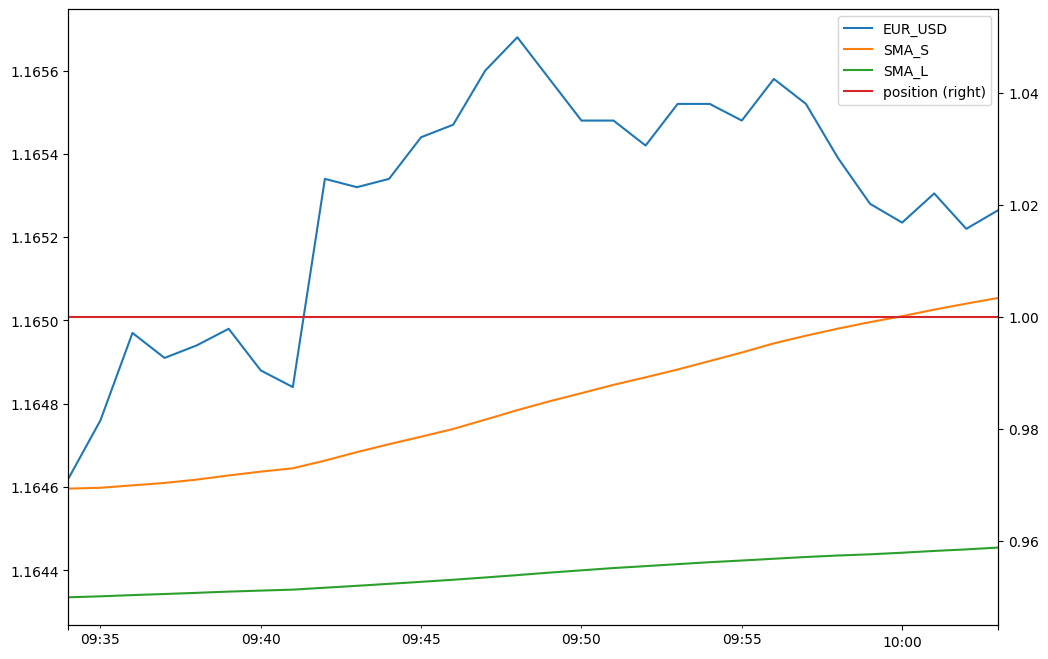

In [133]:
trader.data.tail(30).plot(figsize = (12, 8), secondary_y = "position")
plt.show()

__Strategy 2__: Bollinger Bands SMA 20 (minutes) / 1 Standard Deviation (200 ticks) 

## Stop here if you don´t want to see the solution!

###############################################################

In [134]:
class BollTrader(tpqoa.tpqoa):
    def __init__(self, conf_file, instrument, bar_length, SMA, dev, units):
        super().__init__(conf_file)
        self.instrument = instrument
        self.bar_length = pd.to_timedelta(bar_length)
        self.tick_data = pd.DataFrame()
        self.raw_data = None
        self.data = None 
        self.last_bar = None
        self.units = units
        self.position = 0
        self.profits = []
        
        #*****************add strategy-specific attributes here******************
        self.SMA = SMA
        self.dev = dev
        #************************************************************************
    
    def get_most_recent(self, days = 5):
        while True:
            time.sleep(2)
            now = datetime.now(timezone.utc).replace(tzinfo=None)
            now = now - timedelta(microseconds = now.microsecond)
            past = now - timedelta(days = days)
            df = self.get_history(instrument = self.instrument, start = past, end = now,
                                   granularity = "S5", price = "M", localize = False).c.dropna().to_frame()
            df.rename(columns = {"c":self.instrument}, inplace = True)
            df = df.resample(self.bar_length, label = "right").last().dropna().iloc[:-1]
            self.raw_data = df.copy()
            self.last_bar = self.raw_data.index[-1]
            if pd.to_datetime(datetime.now(timezone.utc)) - self.last_bar < self.bar_length:
                break
                
    def on_success(self, time, bid, ask):
        print(self.ticks, end = " ")
        
        recent_tick = pd.to_datetime(time)
        df = pd.DataFrame({self.instrument:(ask + bid)/2}, 
                          index = [recent_tick])
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()
        
        if recent_tick - self.last_bar > self.bar_length:
            self.resample_and_join()
            self.define_strategy()
            self.execute_trades()
    
    def resample_and_join(self):
        self.raw_data = pd.concat([self.raw_data, self.tick_data.resample(self.bar_length, 
                                                                          label="right").last().ffill().iloc[:-1]])
        self.tick_data = self.tick_data.iloc[-1:]
        self.last_bar = self.raw_data.index[-1]
    
    def define_strategy(self): # "strategy-specific"
        df = self.raw_data.copy()
        
        #******************** define your strategy here ************************
        df["SMA"] = df[self.instrument].rolling(self.SMA).mean()
        df["Lower"] = df["SMA"] - df[self.instrument].rolling(self.SMA).std() * self.dev
        df["Upper"] = df["SMA"] + df[self.instrument].rolling(self.SMA).std() * self.dev
        df["distance"] = df[self.instrument] - df.SMA
        df["position"] = np.where(df[self.instrument] < df.Lower, 1, np.nan)
        df["position"] = np.where(df[self.instrument] > df.Upper, -1, df["position"])
        df["position"] = np.where(df.distance * df.distance.shift(1) < 0, 0, df["position"])
        df["position"] = df.position.ffill().fillna(0)
        #***********************************************************************
        
        self.data = df.copy()
    
    def execute_trades(self):
        if self.data["position"].iloc[-1] == 1:
            if self.position == 0:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING LONG")
            elif self.position == -1:
                order = self.create_order(self.instrument, self.units * 2, suppress = True, ret = True) 
                self.report_trade(order, "GOING LONG")
            self.position = 1
        elif self.data["position"].iloc[-1] == -1: 
            if self.position == 0:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units * 2, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")
            self.position = -1
        elif self.data["position"].iloc[-1] == 0: 
            if self.position == -1:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True) 
                self.report_trade(order, "GOING NEUTRAL")
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING NEUTRAL")
            self.position = 0
    
    def report_trade(self, order, going):
        time = order["time"]
        units = order["units"]
        price = order["price"]
        pl = float(order["pl"])
        self.profits.append(pl)
        cumpl = sum(self.profits)
        print("\n" + 100* "-")
        print("{} | {}".format(time, going))
        print("{} | units = {} | price = {} | P&L = {} | Cum P&L = {}".format(time, units, price, pl, cumpl))
        print(100 * "-" + "\n")  
 

In [135]:
trader = BollTrader("oanda.cfg", "EUR_USD", "1min", SMA = 20, dev = 1, units = 100000)

In [136]:
trader.get_most_recent()
trader.stream_data(trader.instrument, stop = 200)
if trader.position != 0: # if we have a final open position
    close_order = trader.create_order(trader.instrument, units = -trader.position * trader.units, 
                                      suppress = True, ret = True) 
    trader.report_trade(close_order, "GOING NEUTRAL")
    trader.position = 0

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 
----------------------------------------------------------------------------------------------------
2025-12-09T10:04:01.564413547Z | GOING LONG
2025-12-09T10:04:01.564413547Z | units = 100000.0 | price = 1.16534 | P&L = 0.0 | Cum P&L = 0.0
----------------------------------------------------------------------------------------------------

25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 

In [137]:
trader.data

,EUR_USD,SMA,Lower,Upper,distance,position
2025-12-04 10:04:00+00:00,1.167620,NaN,NaN,NaN,NaN,0.0
2025-12-04 10:05:00+00:00,1.167820,NaN,NaN,NaN,NaN,0.0
2025-12-04 10:06:00+00:00,1.167720,NaN,NaN,NaN,NaN,0.0
2025-12-04 10:07:00+00:00,1.167520,NaN,NaN,NaN,NaN,0.0
2025-12-04 10:08:00+00:00,1.167350,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...
2025-12-09 10:03:00+00:00,1.165260,1.165440,1.165309,1.165571,-0.000180,1.0
2025-12-09 10:04:00+00:00,1.165275,1.165437,1.165302,1.165571,-0.000162,1.0
2025-12-09 10:05:00+00:00,1.165280,1.165429,1.165290,1.165568,-0.000149,1.0
2025-12-09 10:06:00+00:00,1.165250,1.165418,1.165274,1.165562,-0.000168,1.0


In [138]:
import matplotlib.pyplot as plt

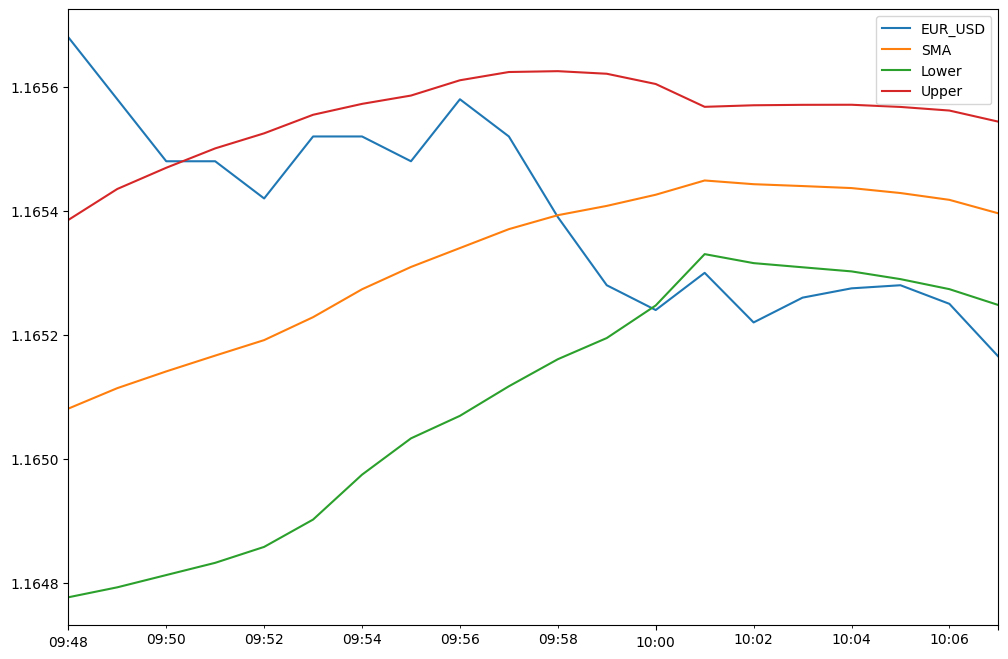

In [139]:
trader.data.tail(20)[["EUR_USD", "SMA", "Lower", "Upper"]].plot(figsize = (12, 8))
plt.show()

## Machine Learning Strategies (1) - Model Fitting

In [140]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier # added (from sklearn v. 1.7)

In [141]:
data = pd.read_csv("five_minute.csv", parse_dates = ["time"], index_col = "time")

In [142]:
data

,price
time,
2019-01-01 22:00:00+00:00,1.146580
2019-01-01 22:05:00+00:00,1.146350
2019-01-01 22:10:00+00:00,1.146320
2019-01-01 22:15:00+00:00,1.146320
2019-01-01 22:20:00+00:00,1.146530
...,...
2019-12-30 23:35:00+00:00,1.120180
2019-12-30 23:40:00+00:00,1.120210
2019-12-30 23:45:00+00:00,1.120295


In [143]:
data["returns"] = np.log(data.div(data.shift(1)))

In [144]:
data.dropna(inplace = True)

In [145]:
data["direction"] = np.sign(data.returns)

In [146]:
data

,price,returns,direction
time,,,
2019-01-01 22:05:00+00:00,1.146350,-0.000201,-1.0
2019-01-01 22:10:00+00:00,1.146320,-0.000026,-1.0
2019-01-01 22:15:00+00:00,1.146320,0.000000,0.0
2019-01-01 22:20:00+00:00,1.146530,0.000183,1.0
2019-01-01 22:25:00+00:00,1.146475,-0.000048,-1.0
...,...,...,...
2019-12-30 23:35:00+00:00,1.120180,-0.000004,-1.0
2019-12-30 23:40:00+00:00,1.120210,0.000027,1.0
2019-12-30 23:45:00+00:00,1.120295,0.000076,1.0


In [147]:
lags = 2

In [148]:
cols = []
for lag in range(1, lags + 1):
    col = "lag{}".format(lag)
    data[col] = data.returns.shift(lag)
    cols.append(col)
data.dropna(inplace = True)

++++++++++++++++++++++++++++

__Scaling/Standardizing Features (new)__

In [149]:
means = data[cols].mean()
means

lag1   -3.121233e-07
lag2   -3.146025e-07
dtype: float64

In [150]:
stand_devs = data[cols].std()
stand_devs

lag1    0.000199
lag2    0.000199
dtype: float64

In [151]:
data[cols] = (data[cols]-means) / stand_devs
data

,price,returns,direction,lag1,lag2
time,,,,,
2019-01-01 22:15:00+00:00,1.146320,0.000000,0.0,-0.130239,-1.008842
2019-01-01 22:20:00+00:00,1.146530,0.000183,1.0,0.001572,-0.130225
2019-01-01 22:25:00+00:00,1.146475,-0.000048,-1.0,0.924174,0.001585
2019-01-01 22:30:00+00:00,1.146455,-0.000017,-1.0,-0.240045,0.924180
2019-01-01 22:35:00+00:00,1.146455,0.000000,0.0,-0.086292,-0.240031
...,...,...,...,...,...
2019-12-30 23:35:00+00:00,1.120180,-0.000004,-1.0,-0.560428,-0.088329
2019-12-30 23:40:00+00:00,1.120210,0.000027,1.0,-0.020909,-0.560412
2019-12-30 23:45:00+00:00,1.120295,0.000076,1.0,0.136458,-0.020897


+++++++++++++++++++++++++++

In [152]:
# lm = LogisticRegression(C = 1e6, max_iter = 100000, multi_class = "ovr") # old

In [153]:
lm = OneVsRestClassifier(LogisticRegression(C = 1e6, max_iter = 100000)) # new (from sklearn v. 1.7)

In [154]:
lm.fit(data[cols], data.direction)

,estimator,LogisticRegre...x_iter=100000)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1000000.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


In [155]:
lm

,estimator,LogisticRegre...x_iter=100000)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1000000.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


__In-Sample "Prediction"__

In [156]:
data["pred"] = lm.predict(data[cols])

In [157]:
data

,price,returns,direction,lag1,lag2,pred
time,,,,,,
2019-01-01 22:15:00+00:00,1.146320,0.000000,0.0,-0.130239,-1.008842,1.0
2019-01-01 22:20:00+00:00,1.146530,0.000183,1.0,0.001572,-0.130225,1.0
2019-01-01 22:25:00+00:00,1.146475,-0.000048,-1.0,0.924174,0.001585,-1.0
2019-01-01 22:30:00+00:00,1.146455,-0.000017,-1.0,-0.240045,0.924180,1.0
2019-01-01 22:35:00+00:00,1.146455,0.000000,0.0,-0.086292,-0.240031,1.0
...,...,...,...,...,...,...
2019-12-30 23:35:00+00:00,1.120180,-0.000004,-1.0,-0.560428,-0.088329,1.0
2019-12-30 23:40:00+00:00,1.120210,0.000027,1.0,-0.020909,-0.560412,1.0
2019-12-30 23:45:00+00:00,1.120295,0.000076,1.0,0.136458,-0.020897,-1.0


In [158]:
hits = np.sign(data.direction * data.pred).value_counts()

In [159]:
hits

 1.0    37472
-1.0    34286
 0.0     1959
Name: count, dtype: int64

In [160]:
hit_ratio = hits[1.0] / sum(hits)
hit_ratio

np.float64(0.5083223679748227)

In [161]:
lm

,estimator,LogisticRegre...x_iter=100000)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1000000.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


__Saving the model__

In [162]:
import pickle

In [163]:
pickle.dump(lm, open("logreg.pkl", "wb"))

__Saving the parameters (mean, std)__ NEW

In [164]:
params = {"mu":means, "std":stand_devs}
params

{'mu': lag1   -3.121233e-07
 lag2   -3.146025e-07
 dtype: float64,
 'std': lag1    0.000199
 lag2    0.000199
 dtype: float64}

In [165]:
pickle.dump(params, open("params.pkl", "wb"))

## Machine Learning Strategies (2) - Implementation

In [166]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier 
import tpqoa
from datetime import datetime, timezone, timedelta
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

In [167]:
class MLTrader(tpqoa.tpqoa):
    def __init__(self, conf_file, instrument, bar_length, lags, model, units):
        super().__init__(conf_file)
        self.instrument = instrument
        self.bar_length = pd.to_timedelta(bar_length)
        self.tick_data = pd.DataFrame()
        self.raw_data = None
        self.data = None 
        self.last_bar = None
        self.units = units
        self.position = 0
        self.profits = []
        
        #*****************add strategy-specific attributes here******************
        self.lags = lags
        self.model = model
        #************************************************************************
    
    def get_most_recent(self, days = 5):
        while True:
            time.sleep(2)
            now = datetime.now(timezone.utc).replace(tzinfo=None)
            now = now - timedelta(microseconds = now.microsecond)
            past = now - timedelta(days = days)
            df = self.get_history(instrument = self.instrument, start = past, end = now,
                                   granularity = "S5", price = "M", localize = False).c.dropna().to_frame()
            df.rename(columns = {"c":self.instrument}, inplace = True)
            df = df.resample(self.bar_length, label = "right").last().dropna().iloc[:-1]
            self.raw_data = df.copy()
            self.last_bar = self.raw_data.index[-1]
            if pd.to_datetime(datetime.now(timezone.utc)) - self.last_bar < self.bar_length:
                break
                
    def on_success(self, time, bid, ask):
        print(self.ticks, end = " ")
        
        recent_tick = pd.to_datetime(time)
        df = pd.DataFrame({self.instrument:(ask + bid)/2}, 
                          index = [recent_tick])
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()
        
        if recent_tick - self.last_bar > self.bar_length:
            self.resample_and_join()
            self.define_strategy()
            self.execute_trades()
    
    def resample_and_join(self):
        self.raw_data = pd.concat([self.raw_data, self.tick_data.resample(self.bar_length, 
                                                                          label="right").last().ffill().iloc[:-1]])
        self.tick_data = self.tick_data.iloc[-1:]
        self.last_bar = self.raw_data.index[-1]
    
    def define_strategy(self): # "strategy-specific"
        df = self.raw_data.copy()
        
        #******************** define your strategy here ************************
        df = pd.concat([df, self.tick_data]) # new with pd.concat
        df["returns"] = np.log(df[self.instrument] / df[self.instrument].shift())
        cols = []
        for lag in range(1, self.lags + 1):
            col = "lag{}".format(lag)
            df[col] = df.returns.shift(lag)
            cols.append(col)
        df.dropna(inplace = True)
        
        df[cols] = (df[cols] - means) / stand_devs # newly added (scaling)
                
        df["position"] = lm.predict(df[cols])
        #***********************************************************************
        
        self.data = df.copy()
    
    def execute_trades(self):
        if self.data["position"].iloc[-1] == 1:
            if self.position == 0:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING LONG")
            elif self.position == -1:
                order = self.create_order(self.instrument, self.units * 2, suppress = True, ret = True) 
                self.report_trade(order, "GOING LONG")
            self.position = 1
        elif self.data["position"].iloc[-1] == -1: 
            if self.position == 0:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units * 2, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")
            self.position = -1
        elif self.data["position"].iloc[-1] == 0: 
            if self.position == -1:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True) 
                self.report_trade(order, "GOING NEUTRAL")
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING NEUTRAL")
            self.position = 0
    
    def report_trade(self, order, going):
        time = order["time"]
        units = order["units"]
        price = order["price"]
        pl = float(order["pl"])
        self.profits.append(pl)
        cumpl = sum(self.profits)
        print("\n" + 100* "-")
        print("{} | {}".format(time, going))
        print("{} | units = {} | price = {} | P&L = {} | Cum P&L = {}".format(time, units, price, pl, cumpl))
        print(100 * "-" + "\n")  

In [168]:
lm = pickle.load(open("logreg.pkl", "rb"))
lm

,estimator,LogisticRegre...x_iter=100000)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1000000.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


+++++++++++++++++++++++++++++++++++++++

__Loading the parameters (mean, std)__ NEW

In [169]:
params = pickle.load(open("params.pkl", "rb"))
params

{'mu': lag1   -3.121233e-07
 lag2   -3.146025e-07
 dtype: float64,
 'std': lag1    0.000199
 lag2    0.000199
 dtype: float64}

In [170]:
means = params["mu"]
stand_devs = params["std"]

In [171]:
means

lag1   -3.121233e-07
lag2   -3.146025e-07
dtype: float64

+++++++++++++++++++++++++++++++++++++++

In [172]:
trader = MLTrader("oanda.cfg", "EUR_USD", "5min", lags = 2, model = lm, units = 100000)

In [173]:
trader.model

,estimator,LogisticRegre...x_iter=100000)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1000000.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


In [174]:
trader.get_most_recent()
trader.stream_data(trader.instrument, stop = 10000)
if trader.position != 0: # if we have a final open position
    close_order = trader.create_order(trader.instrument, units = -trader.position * trader.units, 
                                      suppress = True, ret = True) 
    trader.report_trade(close_order, "GOING NEUTRAL")
    trader.position = 0

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 
----------------------------------------------------------------------------------------------------
2025-12-09T10:10:01.407343902Z | GOING LONG
2025-12-09T10:10:01.407343902Z | units = 100000.0 | price = 1.16517 | P&L = 0.0 | Cum P&L = 0.0
----------------------------------------------------------------------------------------------------

71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 

KeyboardInterrupt: 

In [175]:
trader.data.tail(10)

,EUR_USD,returns,lag1,lag2,position
2025-12-09 10:10:00+00:00,1.165120,-0.000137,0.174465,-1.035678,1.0
2025-12-09 10:15:00+00:00,1.164850,-0.000232,-0.690036,0.174476,1.0
2025-12-09 10:20:00+00:00,1.164845,-0.000004,-1.165732,-0.690019,1.0
2025-12-09 10:25:00+00:00,1.164770,-0.000064,-0.020047,-1.165712,1.0
2025-12-09 10:30:00+00:00,1.164480,-0.000249,-0.322729,-0.020035,1.0
2025-12-09 10:35:00+00:00,1.164440,-0.000034,-1.252587,-0.322714,1.0
2025-12-09 10:40:00+00:00,1.164260,-0.000155,-0.171440,-1.252566,1.0
2025-12-09 10:45:00+00:00,1.164230,-0.000026,-0.777055,-0.171426,1.0
2025-12-09 10:50:00+00:00,1.164290,0.000052,-0.128211,-0.777037,1.0
2025-12-09 10:50:00.370520216+00:00,1.164285,-0.000004,0.261135,-0.128197,-1.0


In [176]:
trader.tick_data

,EUR_USD
2025-12-09 10:50:00.370520216+00:00,1.164285
2025-12-09 10:50:00.877602284+00:00,1.164290
2025-12-09 10:50:01.074718318+00:00,1.164335
2025-12-09 10:50:01.357809336+00:00,1.164335
2025-12-09 10:50:02.395422973+00:00,1.164335
2025-12-09 10:50:02.636317307+00:00,1.164340
2025-12-09 10:50:02.936975182+00:00,1.164345
2025-12-09 10:50:03.109910602+00:00,1.164340
2025-12-09 10:50:03.484673133+00:00,1.164335
2025-12-09 10:50:05.061685193+00:00,1.164355


## Importing a Trader Module / Class

In [177]:
import trader as tr

In [178]:
trader = tr.ConTrader("oanda.cfg", "EUR_USD", "1min", window = 1, units = 100000)
trader.get_most_recent()
trader.stream_data(trader.instrument, stop = 100)
if trader.position != 0: # if we have a final open position
    close_order = trader.create_order(trader.instrument, units = -trader.position * trader.units, 
                                      suppress = True, ret = True) 
    trader.report_trade(close_order, "GOING NEUTRAL")
    trader.position = 0

1 2 3 
----------------------------------------------------------------------------------------------------
2025-12-09T10:51:05.731666758Z | GOING SHORT
2025-12-09T10:51:05.731666758Z | units = -100000.0 | price = 1.16439 | P&L = 0.0 | Cum P&L = 0.0
----------------------------------------------------------------------------------------------------

4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 
----------------------------------------------------------------------------------------------------
2025-12-09T10:52:00.344964040Z | GOING LONG
2025-12-09T10:52:00.344964040Z | units = 200000.0 | price = 1.16449 | P&L = -8.6308 | Cum P&L = -8.6308
----------------------------------------------------------------------------------------------------

53 54 55 56 57 

KeyboardInterrupt: 

In [179]:
trader.data.tail(10)

,EUR_USD,returns,position
2025-12-09 10:43:00+00:00,1.164180,0.000052,-1.0
2025-12-09 10:44:00+00:00,1.164240,0.000052,-1.0
2025-12-09 10:45:00+00:00,1.164230,-0.000009,1.0
2025-12-09 10:46:00+00:00,1.164230,0.000000,-0.0
2025-12-09 10:47:00+00:00,1.164300,0.000060,-1.0
2025-12-09 10:48:00+00:00,1.164220,-0.000069,1.0
2025-12-09 10:49:00+00:00,1.164140,-0.000069,1.0
2025-12-09 10:50:00+00:00,1.164290,0.000129,-1.0
2025-12-09 10:51:00+00:00,1.164470,0.000155,-1.0
2025-12-09 10:52:00+00:00,1.164435,-0.000030,1.0


####################################################################################################

## How to Time/Schedule the End of a Trading Session (Simple Contrarian)

(you can find the corresponding Video for the following lines of code in __Section 26__: Cloud Deployment (AWS) | Scheduling Trading Sessions | Full Automation)

In [180]:
import pandas as pd
import numpy as np
import tpqoa
from datetime import datetime, timezone, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

In [181]:
# datetime.utcnow().time() # current utc time (old)

In [182]:
datetime.now(timezone.utc).time() # new (Python 3.12)

datetime.time(10, 52, 31, 427276)

In [183]:
pd.to_datetime("17:30").time() # desired end of trading session (in utc time)

datetime.time(17, 30)

In [184]:
if datetime.now(timezone.utc).time() >= pd.to_datetime("17:30").time():
    print("Stop the Trading Session!")

In [185]:
class ConTrader(tpqoa.tpqoa):
    def __init__(self, conf_file, instrument, bar_length, window, units):
        super().__init__(conf_file)
        self.instrument = instrument
        self.bar_length = pd.to_timedelta(bar_length)
        self.tick_data = pd.DataFrame()
        self.raw_data = None
        self.data = None 
        self.last_bar = None
        self.units = units
        self.position = 0
        self.profits = []
        
        #*****************add strategy-specific attributes here******************
        self.window = window
        #************************************************************************
    
    def get_most_recent(self, days = 5):
        while True:
            time.sleep(2)
            now = datetime.now(timezone.utc).replace(tzinfo=None)
            now = now - timedelta(microseconds = now.microsecond)
            past = now - timedelta(days = days)
            df = self.get_history(instrument = self.instrument, start = past, end = now,
                                   granularity = "S5", price = "M", localize = False).c.dropna().to_frame()
            df.rename(columns = {"c":self.instrument}, inplace = True)
            df = df.resample(self.bar_length, label = "right").last().dropna().iloc[:-1]
            self.raw_data = df.copy()
            self.last_bar = self.raw_data.index[-1]
            if pd.to_datetime(datetime.now(timezone.utc)) - self.last_bar < self.bar_length:
                break
                
    def on_success(self, time, bid, ask):
        
        print(self.ticks, end = " ")
        
        recent_tick = pd.to_datetime(time)
        
        # define stop
        if recent_tick.time() >= pd.to_datetime("13:00").time():
            self.stop_stream = True
        
        df = pd.DataFrame({self.instrument:(ask + bid)/2}, 
                          index = [recent_tick])
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()
        
        if recent_tick - self.last_bar > self.bar_length:
            self.resample_and_join()
            self.define_strategy()
            self.execute_trades()
    
    def resample_and_join(self):
        self.raw_data = pd.concat([self.raw_data, self.tick_data.resample(self.bar_length, 
                                                                          label="right").last().ffill().iloc[:-1]])
        self.tick_data = self.tick_data.iloc[-1:]
        self.last_bar = self.raw_data.index[-1]
    
    def define_strategy(self): # "strategy-specific"
        df = self.raw_data.copy()
        
        #******************** define your strategy here ************************
        df["returns"] = np.log(df[self.instrument] / df[self.instrument].shift())
        df["position"] = -np.sign(df.returns.rolling(self.window).mean())
        #***********************************************************************
        
        self.data = df.copy()
    
    def execute_trades(self):
        if self.data["position"].iloc[-1] == 1:
            if self.position == 0:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING LONG")
            elif self.position == -1:
                order = self.create_order(self.instrument, self.units * 2, suppress = True, ret = True) 
                self.report_trade(order, "GOING LONG")
            self.position = 1
        elif self.data["position"].iloc[-1] == -1: 
            if self.position == 0:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units * 2, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")
            self.position = -1
        elif self.data["position"].iloc[-1] == 0:
            if self.position == -1:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True) 
                self.report_trade(order, "GOING NEUTRAL")
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True) 
                self.report_trade(order, "GOING NEUTRAL")
            self.position = 0
    
    def report_trade(self, order, going):
        time = order["time"]
        units = order["units"]
        price = order["price"]
        pl = float(order["pl"])
        self.profits.append(pl)
        cumpl = sum(self.profits)
        print("\n" + 100* "-")
        print("{} | {}".format(time, going))
        print("{} | units = {} | price = {} | P&L = {} | Cum P&L = {}".format(time, units, price, pl, cumpl))
        print(100 * "-" + "\n")  
    

In [186]:
trader = ConTrader("oanda.cfg", "EUR_USD", "1min", window = 1, units = 100000)

In [ ]:
trader.get_most_recent()
trader.stream_data(trader.instrument) # no stop after n ticks!
if trader.position != 0: # if we have a final open position
    close_order = trader.create_order(trader.instrument, units = -trader.position * trader.units, 
                                      suppress = True, ret = True) 
    trader.report_trade(close_order, "GOING NEUTRAL")
    trader.position = 0